# Generalized E3SMLE and CESM-SMYLE Atmospheric Skill Maps

This notebook is adapted from `YeagerEA_GMD2022_revision1/f01_fB01_fB03.ipynb` and `YeagerEA_GMD2022_revision1/f02_fB02_fB04.ipynb`. It preserves their lead-time seasonal ACC methodology and map-analysis structure while refactoring data access for the E3SM and CESM-SMYLE comparison and generalizing the workflow across fields.

This notebook computes and plots seasonal skill for `TREFHT`, `TS`, `PRECT`, `PSL`, or ocean-only `SST` using the same workflow.

Change only one line in the configuration cell below:

```python
# field = "TREFHT"  # surface air temperature
# field = "TS"      # all-surface radiative/skin temperature
# field = "PRECT" # precipitation
# field = "PSL"   # sea-level pressure
# field = "SST"   # sea-surface temperature (common E3SM ocean mask)
```

Variable-specific observation product, observation variable name, unit conversion, labels, and cache filenames are handled through `VAR_CONFIG`.

For a small archive-backed restart test, set `WORKFLOW_SETTINGS["run"]["smoke_mode"] = True`; this selects one case/month, five years, two leads, and three resampling iterations. All paths and workflow choices are visible in the configuration cells below. The default `inventory` identity mode fingerprints the exact input files by relative path, size, and modification time. For an archive-free restart after an inventory run, set `cache.source_identity_mode="snapshot"` and `prepared_skill.mode="require"`. This trusts the last recorded inventory for the same source request; it does not check for archive changes. Prepared observations are cached too. Use `revision` only as a separate manual identity scheme, updating revision tokens whenever files change; it does not reuse inventory identities. Seasonal `lead_start`/`lead_end` are inclusive, one-based positions (1–8 for 24 monthly leads).


In [1]:
%load_ext autoreload
%autoreload 2
import os
from pathlib import Path
import xarray as xr 
import numpy as np  
import cftime
import copy
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import xesmf as xe
import xskillscore as xs
%matplotlib inline

# import ESP-Lab modules
#from esp_lab import data_access_smyle.py as data_access
from esp_lab import data_access_e3sm as data_access
from esp_lab import data_access_cesm_smyle as smyle_access
from esp_lab import data_access_obs as obs_access
from esp_lab import stats
from esp_lab.prepared_skill import (
    build_prepared_skill_dataset,
    cache_status,
    expected_prepared_skill_attrs,
    open_prepared_skill_dataset,
    prepared_skill_cache_status,
    prepared_skill_path,
    write_prepared_skill_dataset,
)
from esp_lab.leadtime_skill_cache import (
    SkillComparisonCacheLayout,
    acc_superiority_fraction,
    cache_comparison_anomaly,
    expected_skill_cache_attrs,
    file_inventory_digest,
    generate_member_indices,
    load_or_write_member_selection,
    member_selection_attrs,
    source_fingerprint,
    stable_resampling_seed,
    verification_year_token,
    year_number,
)

# import plotting and other utilities from esp_lab.utils (formerly SMYLEutils)
from esp_lab.utils import calendar_utils as cal
from esp_lab.utils import mapplot_utils as maps
from esp_lab.utils import colorbar_utils as cbars
from esp_lab.utils import regrid_utils as regrid
from esp_lab.utils import mov_utils as mov
from esp_lab.utils.filename_utils import figure_filename
from esp_lab.utils.netcdf_utils import atomic_to_netcdf, load_netcdf
from esp_lab.utils.resource_utils import ResourceTracker
from esp_lab.utils.unit_conversion import (
    convert_kelvin_to_celsius,
    convert_pa_to_hpa,
    convert_precip_mps_to_mmday,
    no_unit_conversion,
)
from esp_lab.leadtime_plot_utils import (
    add_acc_comparison_markers,
    seasonal_label,
    style_global_map_axis,
)
from esp_lab.leadtime_validation import check_remove_drift_sample
from esp_lab.leadtime_workflow import (
    compute_skill_lead_range,
    compute_skill_lead_range_batch,
    ocean_mask_identity,
    resolve_source_revision,
    seasonal_cache_encoding,
)
from esp_lab.paths import leadtime_acc_dir

from esp_lab.utils.dask_util import DaskConfig, get_cluster_client, close_cluster


In [2]:
import dask
from dask.distributed import (
    wait,
    get_client
)
dask.__version__

'2026.3.0'

## Preprocessing:  Data I/O using Dask

### Create Dask Cluster

In [ ]:
from esp_lab.utils.notebook_resources import restart_notebook_cluster, close_notebook_resources

# User-adjustable Dask settings (shared login nodes are capped at four workers).
machine_env = "local"
dask_workers = 4

dask_cfg = DaskConfig(cluster_type=machine_env, workers=dask_workers)
cluster, client, workflow_resources = restart_notebook_cluster(
    globals(), lambda: get_cluster_client(dask_cfg)
)



!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
This can easily exceed memory/CPU limits and crash your Jupyter kernel.
We highly recommend launching Jupyter on an Exclusive Perlmutter Compute Node.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Scheduler: tcp://127.0.0.1:34825
Connected workers: 4
Dashboard: http://127.0.0.1:8787/status


2026-09-07 20:03:33,180 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 37d4aa20d1f15966691ed2293180360d initialized by task ('rechunk-merge-rechunk-transfer-1eff6937f23efc91f7a066b2027e2a2f', 0, 2, 1, 0, 2, 1) executed on worker tcp://127.0.0.1:45283
2026-09-07 20:03:33,282 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 36bfbfd309a488575f93d38ef3f89d58 initialized by task ('rechunk-merge-rechunk-transfer-1eff6937f23efc91f7a066b2027e2a2f', 0, 2, 0, 0, 2, 0) executed on worker tcp://127.0.0.1:33005
2026-09-07 20:03:34,422 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 37d4aa20d1f15966691ed2293180360d deactivated due to stimulus 'task-finished-1788836614.4211829'
2026-09-07 20:03:34,425 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 36bfbfd309a488575f93d38ef3f89d58 deactivated due to stimulus 'task-finished-1788836614.4242122'
2026-09-07 20:03:34,536 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 4689764c44c74abd0260e6b98ed8

In [4]:
cluster

LocalCluster(30a113e1, 'tcp://127.0.0.1:34825', workers=4, threads=4, memory=14.90 GiB)

### User setup and workflow configuration

Select the diagnostic field, E3SM cases, run years, paths, cache behavior, regridding, significance settings, and figure options here.

In [5]:
%%time
# -----------------------------------------------------------------------------
# Variable-driven setup + multi-case E3SM hindcast setup
# -----------------------------------------------------------------------------
VAR_CONFIG = {
    "TREFHT": {
        "long_name": "2-m air temperature",
        "plot_name": "Surface air temperature",
        "obs_name": "ERA5",
        "obs_var": "tas",
        "obs_ys": "1979",
        "obs_ye": "2019",
        "model_convert": convert_kelvin_to_celsius,
        "smyle_convert": convert_kelvin_to_celsius,
        "obs_convert": convert_kelvin_to_celsius,
        "units": r"$^\circ$C",
    },
    "TS": {
        "long_name": "surface radiative temperature",
        "plot_name": "Surface temperature",
        "obs_name": "ERA5",
        "obs_var": "ts",
        "obs_ys": "1979",
        "obs_ye": "2019",
        "model_convert": convert_kelvin_to_celsius,
        "smyle_convert": convert_kelvin_to_celsius,
        "obs_convert": convert_kelvin_to_celsius,
        "units": r"$^\circ$C",
    },
    "PRECT": {
        "long_name": "precipitation",
        "plot_name": "Precipitation",
        "obs_name": "GPCP_v2.3",
        "obs_var": "PRECT",
        "obs_ys": "1979",
        "obs_ye": "2017",
        "model_convert": convert_precip_mps_to_mmday,
        "smyle_convert": convert_precip_mps_to_mmday,
        # GPCP PRECT from this archive is already mm/day.
        "obs_convert": lambda da: no_unit_conversion(da, units="mm/day"),
        "units": "mm/day",
    },
    "PSL": {
        "long_name": "sea-level pressure",
        "plot_name": "Sea-level pressure",
        "obs_name": "ERA5",
        "obs_var": "psl",
        "obs_ys": "1979",
        "obs_ye": "2019",
        "model_convert": convert_pa_to_hpa,
        "smyle_convert": convert_pa_to_hpa,
        "obs_convert": convert_pa_to_hpa,
        "units": "hPa",
    },
    "SST": {
        "long_name": "sea-surface temperature",
        "plot_name": "Sea-surface temperature",
        "component": "ocn",
        "e3sm_realm": "ocn",
        "e3sm_field": "timeMonthly_avg_activeTracers_temperature",
        "smyle_field": "TS",
        "obs_name": "HadISST2",
        "obs_var": "sst",
        "obs_ys": "1979",
        "obs_ye": "2022",
        # E3SM MPAS-O and HadISST2 are already in Celsius; SMYLE TS is Kelvin.
        "model_convert": lambda da: no_unit_conversion(da, units=r"$^\circ$C"),
        "smyle_convert": convert_kelvin_to_celsius,
        "obs_convert": lambda da: no_unit_conversion(da, units=r"$^\circ$C"),
        "units": r"$^\circ$C",
        "ocean_only": True,
    },
}

# Change this one line to switch diagnostics:
#   field = "TREFHT"  -> ERA5 tas, model/obs K -> degC
#   field = "TS"      -> ERA5 ts, model/obs K -> degC (land and ocean)
#   field = "PRECT"   -> GPCP PRECT, model m/s -> mm/day
#   field = "PSL"     -> ERA5 psl, model/obs Pa -> hPa
#   field = "SST"     -> HadISST2 sst, E3SM surface ocean temperature, SMYLE TS
#field = "PRECT"
#field = "TREFHT"
field = "TS"
#field = "PSL"
#field = "SST"

if field not in VAR_CONFIG:
    raise ValueError(f"Unsupported field={field!r}. Available fields: {list(VAR_CONFIG)}")

cfg = VAR_CONFIG[field]
analysis_component = cfg.get('component', 'atm')
e3sm_field = cfg.get('e3sm_field', field)
smyle_field = cfg.get('smyle_field', field)
print(f"Selected field: {field} ({cfg['long_name']})")
print(f"Observation product: {cfg['obs_name']} variable={cfg['obs_var']}")
print(f"Archive mapping: E3SM {analysis_component}/{e3sm_field}; CESM-SMYLE {smyle_field}")

# Multi-case E3SM hindcasts. Add more entries here as new post-processed
# hindcasts land under data_dir with the same directory convention.
E3SM_CASES = {
    "E3SM-FOSIRL": {
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL",
        "cache_tag": "JRA55_FOSIRL",
        "display_name": "E3SMv3-FOSIRL",
        "source_revision": "post_process_v1",
    },
    "E3SM-Reanalysis": {
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce",
        "cache_tag": "Reanalysis",
        "display_name": "E3SMv3-Reanalysis",
        "source_revision": "post_process_v1",
    },
    "E3SM-4DEnVarOcn": {
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVarOcn",
        "cache_tag": "4DEnVarOcn",
        "display_name": "E3SMv3-4DEnVarOcn",
        "source_revision": "post_process_v1",
    },
}

# Which E3SM case should old single-case cells/variables point to.
E3SM_REFERENCE_CASE = "E3SM-FOSIRL"

# Central workflow settings. Edit this block first; later cells consume these
# values so run-control, grid, and chunk choices stay consistent.
WORKFLOW_SETTINGS = {
    "paths": {
        # Explicit Perlmutter paths for diagnostic data and generated figures.
        "s2d_diag_root": "/global/cfs/cdirs/e3sm/S2S2D/s2d_diag",
        "figure_outdir": "/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag",
    },
    "run": {
        "smoke_mode": False,
        "years": (1980,2011), #(1980, 2018),
        "exclude_year": None,
        "init_months": [5, 11],
        "climatology_years": (1981, 2010),
    },
    "e3sm": {
        # Required raw E3SM archive input; no automatic fallback search.
        "data_dir": "/global/cfs/cdirs/e3sm/S2S2D/post_process",
        "nens": 10,
        "nlead": 24,
        "engine": "netcdf4",
        "realm": "atm",
        "grid": "180x360_aave",
        "freq": "monthly",
        "ts_split": "2yr",
        "require_all_members": True,
        "verify_field_name": True,
        "verify_coverage": True,
        "open_chunks": {},  # e.g., {"L": 24} if open-time chunking is needed.
        "monthly_chunks": {"Y": 3, "L": 24, "M": 2, "lat": 90, "lon": 180},
        # Desired Y, L, M, lat, lon chunks; capped to each seasonal array.
        "encoding_chunksizes": (1, 8, 1, 90, 180),
    },
    "regrid": {
        "target_dlat": 1.0,
        "target_dlon": 1.0,
        "method": "conservative",
        "periodic": True,
    },
    "smyle": {
        # Required preprocessed reference-model benchmark directory.
        "benchmark_dir": "/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE",
        "nens": 20,
        "nlead": 24,
        # Used directly in revision mode and as an extra invalidation token in inventory mode.
        "source_revision": "benchmark_v1",
        "chunks": {"Y": 3, "L": -1, "M": 2, "lat": 96, "lon": 144},
    },
    "obs": {
        # Required top-level observational time-series archive.
        "data_dir": "/global/cfs/cdirs/e3sm/e3sm_diags/obs_for_e3sm_diags/time-series",
        "verbose": True,
        # Used directly in revision mode and as an extra invalidation token in inventory mode.
        "source_revision": "obs_archive_v1",
        "chunks": {"time": 24, "lat": 90, "lon": 180},
    },
    "prepared_skill": {
        "mode": "auto",  # "auto", "rebuild", or "require"
        "force_recompute": False,
        "chunks": {"Y": 3, "L": 1, "M": 2, "lat": 45, "lon": 90},
    },
    "skill": {
        "force_compute": False,
        "detrend": True,
        "lead_start": 1,  # Inclusive one-based seasonal position.
        "lead_end": 8,
        "model_chunks": {"Y": -1, "L": 8, "M": 2, "lat": 45, "lon": 90},
        "obs_chunks": {"time": -1, "lat": 45, "lon": 90},
    },
    "finite_ensemble_compare": {
        "mode": "final",  # "test" or "final"
        "case_selection": "all",
        "force_recompute": False,
        "detrend": True,
        "random_seed": 42,
        "cache_anomalies": True,
        "persist_inputs": False,
        "model_chunks": {"Y": -1, "M": -1, "L": 1, "lat": 30, "lon": 60},
        "obs_chunks": {"time": -1, "lat": 30, "lon": 60},
        "iteration_batch_size": 10,
        "modes": {
            "test": {"init_months": [11], "iterations": 10, "lead_start": 1, "lead_end": 8},
            "final": {"init_months": [5, 11], "iterations": 100, "lead_start": 1, "lead_end": 8},
        },
    },
    "final_acc_figures": {
        "init_months": [5, 11],
        "max_leads": 7,
        "geometry": {
            "fig_col_width": 4.4,
            "fig_row_height": 2.8,
            "section_gap": 0.04,
            "section_gap_fig_width": 1.2,
            "tight_layout_rect": [0.0, 0.11, 1.0, 0.94],
            "subplots_top": 0.94,
            "subplots_bottom": 0.11,
            "subplots_hspace": 0.06,
            "subplots_wspace": 0.025,
            "month_header_y": 0.955,
            "divider_y0": 0.08,
            "divider_y1": 0.94,
            "divider_color": "0.25",
            "divider_linewidth": 1.0,
            "cbar_rect": [0.3, 0.03, 0.5, 0.015],
        },
        "markers": {
            "sig_level": 0.1,
            "latlim": 80,
            "marker_color": "black",
            "marker_stride": 5,
            "open_marker_size": 12,
            "filled_marker_size": 5,
            "marker_linewidth": 0.65,
            "grid_linewidth": 0.35,
            "grid_color": "0.35",
            "grid_alpha": 0.35,
            "tick_length": 2.5,
            "tick_width": 0.5,
            "label_bbox": {
                "boxstyle": "round,pad=0.2",
                "facecolor": "white",
                "edgecolor": "lightgray",
                "alpha": 0.85,
                "linewidth": 0.8,
            },
        },
        "acc": {
            "include_cesm_smyle": True,
            "cesm_label": "CESM-SMYLE",
            "ci": 0.1,
            "cmin": -1,
            "cmax": 1,
            "cmap": "blue2red_acc",
            "cutoff": 0.5,
            "fontz": 14,
            "title_template": "{plot_name} ACC: CESM-SMYLE and E3SM, {trend_label}",
            "caption": "ACC comparison for CESM-SMYLE and selected E3SM hindcasts.",
        },
        "skilldiff": {
            "ci": 0.05,
            "cmin": -0.5,
            "cmax": 0.5,
            "cmap": "blue2red",
            "cutoff": 0.5,
            "fontz": 16,
            "title_template": "{plot_name} ACC difference: E3SM minus matched CESM-SMYLE, {trend_label}",
            "save_title_template": "Leadtime ACC Skill Difference: {field}",
            "caption": "ACC skill difference for selected E3SM hindcasts.",
        },
        "font_weight": "bold",
    },
    "diagnostics": {
        # Full drift checks can materialize large arrays; keep them opt-in.
        "run_drift_check": False,
        "drift_check_sample": {"Y": 0, "M": 0, "lat": 0, "lon": 0},
        # The pre-significance ACC overview is useful but large; keep saved
        # output enabled while avoiding an expensive inline notebook render.
        "make_pre_significance_acc_plot": True,
        "pre_significance_acc_dpi": 300,
        "show_pre_significance_acc_plot": False,
    },
    "cache": {
        # "inventory" fingerprints the exact files (path, size, mtime).
        # "snapshot" reuses a recorded inventory without archive access;
        # pair it with prepared_skill.mode="require" after an inventory run.
        # "revision" is a separate manual scheme, not an inventory fallback.
        "source_identity_mode": "inventory",
        "force_rewrite_inputs": False,
        "debug_load": False,
        "debug_seasonal_cache": False,
        "cleanup_temp_files": True,
        # Avoid deleting temporary files belonging to another active run.
        "temp_file_max_age_hours": 24.0,
    },
}

smoke_mode = bool(WORKFLOW_SETTINGS["run"]["smoke_mode"])
if smoke_mode:
    # Small archive-backed execution for restart/provenance validation.
    E3SM_CASES = {E3SM_REFERENCE_CASE: E3SM_CASES[E3SM_REFERENCE_CASE]}
    WORKFLOW_SETTINGS["run"].update(
        years=(1980, 1984), init_months=[11], climatology_years=(1980, 1984)
    )
    WORKFLOW_SETTINGS["regrid"].update(target_dlat=5.0, target_dlon=5.0)
    WORKFLOW_SETTINGS["skill"].update(lead_start=1, lead_end=2)
    WORKFLOW_SETTINGS["finite_ensemble_compare"].update(
        mode="test", case_selection=E3SM_REFERENCE_CASE, iteration_batch_size=3
    )
    WORKFLOW_SETTINGS["finite_ensemble_compare"]["modes"]["test"] = {
        "init_months": [11], "iterations": 3, "lead_start": 1, "lead_end": 2
    }
    WORKFLOW_SETTINGS["final_acc_figures"].update(init_months=[11], max_leads=2)
    WORKFLOW_SETTINGS["diagnostics"]["make_pre_significance_acc_plot"] = False
    print("ESP-Lab smoke mode enabled: one case/month, five years, two leads.")


Selected field: TS (surface radiative temperature)
Observation product: ERA5 variable=ts
Archive mapping: E3SM atm/TS; CESM-SMYLE TS
CPU times: user 742 μs, sys: 0 ns, total: 742 μs
Wall time: 700 μs


### Initialize workflow paths and plan prepared-cache work

In [6]:
def e3sm_leadtime_dir(case_info, stage, *parts):
    return leadtime_acc_dir(
        case_info["cache_tag"], stage, analysis_component, *parts,
        root=S2D_DIAG_ROOT,
    )

def smyle_leadtime_dir(stage, *parts):
    return leadtime_acc_dir(
        "CESM-SMYLE", stage, analysis_component, *parts,
        root=S2D_DIAG_ROOT,
    )

def build_plot_subtitle(plot_name: str, workflow_settings: dict, detrend: bool) -> str:
    """Build a compact figure subtitle from the configured run window."""
    year_start, year_end = workflow_settings["run"]["years"]
    year_label = f"{year_start}–{year_end}"
    trend_label = "linear-detrend" if detrend else "no-detrend"
    return f"{plot_name} skill ({year_label}, {trend_label})"

netcdf_write_options = {
    "cleanup_temporary": WORKFLOW_SETTINGS["cache"].get("cleanup_temp_files", True),
    "temp_file_max_age_hours": WORKFLOW_SETTINGS["cache"].get("temp_file_max_age_hours", 24.0),
}


years, yeare = WORKFLOW_SETTINGS["run"]["years"]
yexcl = WORKFLOW_SETTINGS["run"]["exclude_year"]
init_months = list(WORKFLOW_SETTINGS["run"]["init_months"])
climy0, climy1 = WORKFLOW_SETTINGS["run"]["climatology_years"]

required_directory_settings = {
    "paths.s2d_diag_root": WORKFLOW_SETTINGS.get("paths", {}).get("s2d_diag_root"),
    "paths.figure_outdir": WORKFLOW_SETTINGS.get("paths", {}).get("figure_outdir"),
    "e3sm.data_dir": WORKFLOW_SETTINGS.get("e3sm", {}).get("data_dir"),
    "smyle.benchmark_dir": WORKFLOW_SETTINGS.get("smyle", {}).get("benchmark_dir"),
    "obs.data_dir": WORKFLOW_SETTINGS.get("obs", {}).get("data_dir"),
}
missing_directory_settings = [
    name for name, value in required_directory_settings.items() if not value
]
if missing_directory_settings:
    raise ValueError(
        "Set all required directory entries in WORKFLOW_SETTINGS; missing: "
        + ", ".join(missing_directory_settings)
    )

S2D_DIAG_ROOT = Path(required_directory_settings["paths.s2d_diag_root"])
FIGURE_OUTDIR = Path(required_directory_settings["paths.figure_outdir"])
SMYLE_BENCHMARK_DIR = Path(WORKFLOW_SETTINGS["smyle"]["benchmark_dir"])

FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)
print(f"Using configured diagnostic root: {S2D_DIAG_ROOT}")
print(f"Using configured figure directory: {FIGURE_OUTDIR}")

data_dir = str(WORKFLOW_SETTINGS["e3sm"]["data_dir"])
print(f"Using configured E3SM post-processed data directory: {data_dir}")

case_nens = WORKFLOW_SETTINGS["e3sm"]["nens"]
case_nlead = WORKFLOW_SETTINGS["e3sm"]["nlead"]
engine = WORKFLOW_SETTINGS["e3sm"]["engine"]
realm = cfg.get("e3sm_realm", WORKFLOW_SETTINGS["e3sm"]["realm"])
grid = WORKFLOW_SETTINGS["e3sm"]["grid"]
freq = WORKFLOW_SETTINGS["e3sm"]["freq"]
ts_split = WORKFLOW_SETTINGS["e3sm"]["ts_split"]
require_all_members = WORKFLOW_SETTINGS["e3sm"]["require_all_members"]
verify_field_name = WORKFLOW_SETTINGS["e3sm"]["verify_field_name"]
verify_coverage = WORKFLOW_SETTINGS["e3sm"]["verify_coverage"]
chunks_open = dict(WORKFLOW_SETTINGS["e3sm"]["open_chunks"])
mchunk = dict(WORKFLOW_SETTINGS["e3sm"]["monthly_chunks"])
debug = WORKFLOW_SETTINGS["cache"]["debug_load"]

if E3SM_REFERENCE_CASE not in E3SM_CASES:
    raise ValueError("E3SM_REFERENCE_CASE must be present in E3SM_CASES")
if not init_months or len(set(init_months)) != len(init_months) or any(
    not isinstance(m, int) or not 1 <= m <= 12 for m in init_months
):
    raise ValueError("run.init_months must contain unique months from 1 to 12")
if len({info["cache_tag"] for info in E3SM_CASES.values()}) != len(E3SM_CASES):
    raise ValueError("E3SM cases must have distinct cache_tag values")
if climy0 > climy1:
    raise ValueError("climatology_years must be ordered")
for family in ("e3sm", "smyle"):
    monthly_leads = WORKFLOW_SETTINGS[family]["nlead"]
    if monthly_leads < 3 or monthly_leads % 3:
        raise ValueError(f"{family}.nlead must be a positive multiple of three")
compare_setup = WORKFLOW_SETTINGS["finite_ensemble_compare"]
if compare_setup["mode"] not in compare_setup["modes"]:
    raise ValueError("Unknown finite_ensemble_compare.mode")
compare_run_setup = compare_setup["modes"][compare_setup["mode"]]
for lead_config in (WORKFLOW_SETTINGS["skill"], compare_run_setup):
    start, end = lead_config["lead_start"], lead_config["lead_end"]
    if (any(isinstance(v, bool) or not isinstance(v, int) for v in (start, end))
            or not 1 <= start <= end <= min(case_nlead, WORKFLOW_SETTINGS["smyle"]["nlead"]) // 3):
        raise ValueError(f"Invalid inclusive seasonal lead range: {start}-{end}")
if compare_setup["detrend"] != WORKFLOW_SETTINGS["skill"]["detrend"]:
    raise ValueError("skill.detrend and finite_ensemble_compare.detrend must match")
if compare_run_setup["iterations"] < 1 or compare_setup["iteration_batch_size"] < 1:
    raise ValueError("Comparison iterations and iteration_batch_size must be positive")
if WORKFLOW_SETTINGS["final_acc_figures"]["acc"]["include_cesm_smyle"] and not (
    WORKFLOW_SETTINGS["skill"]["lead_start"] <= compare_run_setup["lead_start"]
    <= compare_run_setup["lead_end"] <= WORKFLOW_SETTINGS["skill"]["lead_end"]
):
    raise ValueError("The CESM figure column requires skill leads to cover comparison leads")
lead_years = [y for y in np.arange(years, yeare + 1) if y != yexcl]
if len(lead_years) < 3:
    raise ValueError("At least three initialization years are required")
figure_verification_token = verification_year_token(lead_years)
figure_init_token = "init_" + "-".join(f"{month:02d}" for month in init_months)
figure_trend_token = (
    "detrend" if WORKFLOW_SETTINGS["skill"]["detrend"] else "nodetrend"
)
run_year_token = f"y{lead_years[0]}-{lead_years[-1]}_ny{len(lead_years)}_ex{yexcl or 'none'}"
INIT_YEARS_BY_MONTH = {init_month: lead_years for init_month in init_months}
members = [f"EN{i:02d}" for i in range(case_nens)]

prepared_cfg = WORKFLOW_SETTINGS["prepared_skill"]
prepared_mode = prepared_cfg["mode"]
prepared_force_recompute = prepared_cfg["force_recompute"]
prepared_chunks = dict(prepared_cfg["chunks"])
if prepared_mode not in {"auto", "rebuild", "require"}:
    raise ValueError("prepared_skill.mode must be 'auto', 'rebuild', or 'require'")
if prepared_mode == "require" and prepared_force_recompute:
    raise ValueError("prepared_skill.force_recompute cannot be used with mode='require'")

# SST prepared bundles now retain their unmasked source domain. Invalidate
# older bundles that irreversibly embedded a multi-case common mask.
UNIT_CONVERSION_VERSION = (
    "leadtime_skill_units_v2_unmasked_sst" if field == "SST"
    else "leadtime_skill_units_v1"
)
target_grid_identity = (
    f"latlon_{WORKFLOW_SETTINGS['regrid']['target_dlat']}x"
    f"{WORKFLOW_SETTINGS['regrid']['target_dlon']}_"
    f"periodic-{WORKFLOW_SETTINGS['regrid']['periodic']}"
)

source_identity_mode = WORKFLOW_SETTINGS["cache"].get("source_identity_mode", "inventory")
if source_identity_mode not in {"inventory", "snapshot", "revision"}:
    raise ValueError("cache.source_identity_mode must be inventory, snapshot, or revision")
if source_identity_mode == "snapshot" and prepared_mode != "require":
    raise ValueError("Snapshot mode requires prepared_skill.mode='require'")

def _source_revision(configured_revision, paths, root, identity):
    return resolve_source_revision(
        source_identity_mode, configured_revision,
        identity={"archive_root": str(root), **identity},
        snapshot_dir=S2D_DIAG_ROOT / "source_inventory_snapshots",
        paths=paths, root=root,
    )

e3sm_source_revision_by_case_month = {}
for case_key, case_info in E3SM_CASES.items():
    cache_tag = case_info["cache_tag"]
    e3sm_source_revision_by_case_month[cache_tag] = {}
    for init_month in init_months:
        if source_identity_mode == "inventory":
            requested_init_tags = data_access.build_init_tags(
                INIT_YEARS_BY_MONTH[init_month], init_month
            )
            nested_files, valid_init_tags = data_access.nested_file_list_by_init(
                data_dir=data_dir, case_prefix=case_info["case_prefix"],
                members=members, init_tags=requested_init_tags, field=e3sm_field,
                realm=realm, grid=grid, freq=freq, ts_split=ts_split,
                require_all_members=require_all_members,
                verify_field_name=verify_field_name, verify_coverage=verify_coverage,
                nlead=case_nlead,
            )
            if valid_init_tags != requested_init_tags:
                missing = sorted(set(requested_init_tags) - set(valid_init_tags))
                raise FileNotFoundError(
                    f"Incomplete E3SM source inventory for {case_key}, month "
                    f"{init_month:02d}; missing initializations: {missing}"
                )
            source_files = [path for files in nested_files for path in files]
        else:
            source_files = []
        e3sm_source_revision_by_case_month[cache_tag][init_month] = _source_revision(
            case_info["source_revision"], source_files, data_dir,
            {"case_prefix": case_info["case_prefix"], "field": e3sm_field,
             "realm": realm, "grid": grid, "freq": freq, "ts_split": ts_split,
             "members": members, "nlead": case_nlead,
             "years": [int(y) for y in lead_years], "init_month": init_month},
        )

smyle_source_revision_by_month = {}
for init_month in init_months:
    source_files = (
        [smyle_access.benchmark_path(
            smyle_field, init_month, SMYLE_BENCHMARK_DIR,
            nens=WORKFLOW_SETTINGS["smyle"]["nens"],
            nlead=WORKFLOW_SETTINGS["smyle"]["nlead"], freq="seas",
        )]
        if source_identity_mode == "inventory" else []
    )
    smyle_source_revision_by_month[init_month] = _source_revision(
        WORKFLOW_SETTINGS["smyle"]["source_revision"],
        source_files, SMYLE_BENCHMARK_DIR,
        {"field": smyle_field, "init_month": init_month, "freq": "seas",
         "nens": WORKFLOW_SETTINGS["smyle"]["nens"],
         "nlead": WORKFLOW_SETTINGS["smyle"]["nlead"]},
    )
print(f"Source identity mode: {source_identity_mode}")

def _prepared_spec(source, init_month, case_info=None):
    is_smyle = source == "CESM-SMYLE"
    case_prefix = (
        "b.e21.BSMYLE.f09_g17" if is_smyle else case_info["case_prefix"]
    )
    source_identity_fields = (
        {"archive_root": str(SMYLE_BENCHMARK_DIR), "case_prefix": case_prefix,
         "field": smyle_field, "frequency": "seasonal"}
        if is_smyle
        else {"archive_root": data_dir, "case_prefix": case_prefix,
              "realm": realm, "grid": grid, "frequency": freq,
              "time_split": ts_split, "field": e3sm_field}
    )
    source_revision = (
        smyle_source_revision_by_month[init_month]
        if is_smyle
        else e3sm_source_revision_by_case_month[source][init_month]
    )
    source_data_identity = source_fingerprint(
        source_identity_fields, source_revision=source_revision
    )
    provenance = dict(
        source_data_identity=source_data_identity,
        case_prefix=case_prefix,
        requested_years=INIT_YEARS_BY_MONTH[init_month],
        target_grid=target_grid_identity,
        regridding_method=WORKFLOW_SETTINGS["regrid"]["method"],
        ensemble_member_count=(
            WORKFLOW_SETTINGS["smyle"]["nens"] if is_smyle else case_nens
        ),
        lead_count=(
            WORKFLOW_SETTINGS["smyle"]["nlead"] // 3 if is_smyle else case_nlead // 3
        ),
        unit_conversion_version=UNIT_CONVERSION_VERSION,
    )
    path = prepared_skill_path(
        source, analysis_component, field, init_month, (climy0, climy1),
        root=S2D_DIAG_ROOT, **provenance,
    )
    expected = expected_prepared_skill_attrs(
        source=source, component=analysis_component, variable=field,
        init_month=init_month, climatology_years=(climy0, climy1),
        **provenance,
    )
    return path, expected

prepared_specs_by_case_month = {
    case_key: {
        init_month: _prepared_spec(case_info["cache_tag"], init_month, case_info)
        for init_month in init_months
    }
    for case_key, case_info in E3SM_CASES.items()
}
smyle_prepared_specs_by_month = {
    init_month: _prepared_spec("CESM-SMYLE", init_month)
    for init_month in init_months
}
prepared_required_specs = [
    spec for by_month in prepared_specs_by_case_month.values()
    for spec in by_month.values()
] + list(smyle_prepared_specs_by_month.values())
unavailable_prepared = []
for path, expected in prepared_required_specs:
    compatible, reason = prepared_skill_cache_status(path, expected_attrs=expected)
    if not compatible:
        unavailable_prepared.append((path, reason))
if prepared_mode == "require" and unavailable_prepared:
    details = "\n".join(
        f"  - {path}: {reason}" for path, reason in unavailable_prepared
    )
    raise RuntimeError(f"Required prepared skill inputs are unavailable:\n{details}")
def _needs_preparation(spec):
    compatible, _ = prepared_skill_cache_status(spec[0], expected_attrs=spec[1])
    return prepared_force_recompute or prepared_mode == "rebuild" or not compatible

e3sm_months_to_prepare = {
    case_key: [month for month, spec in by_month.items() if _needs_preparation(spec)]
    for case_key, by_month in prepared_specs_by_case_month.items()
}
smyle_months_to_prepare = [
    month for month, spec in smyle_prepared_specs_by_month.items()
    if _needs_preparation(spec)
]
seasonal_force_rewrite = WORKFLOW_SETTINGS["cache"]["force_rewrite_inputs"]
seasonal_input_specs_by_case_month = {}
for case_key, case_info in E3SM_CASES.items():
    seasonal_input_specs_by_case_month[case_key] = {}
    for init_month in e3sm_months_to_prepare[case_key]:
        cache_tag = case_info["cache_tag"]
        filename = (
            f"{cache_tag}_{init_month:02d}_{field}_{run_year_token}_"
            f"N{case_nens:02d}_M{case_nlead:02d}_seas.nc"
        )
        path = e3sm_leadtime_dir(case_info, "inputs", field) / filename
        expected = dict(
            prepared_specs_by_case_month[case_key][init_month][1],
            cache_kind="seasonal_e3sm_input",
        )
        seasonal_input_specs_by_case_month[case_key][init_month] = (path, expected)

e3sm_months_to_load_raw = {
    case_key: [
        month for month, (path, expected) in by_month.items()
        if seasonal_force_rewrite or not cache_status(
            path, expected_attrs=expected, required_variables=(field,),
        )[0]
    ]
    for case_key, by_month in seasonal_input_specs_by_case_month.items()
}
use_prepared_skill_inputs = not any(e3sm_months_to_prepare.values()) and not smyle_months_to_prepare
print("Prepared E3SM inputs to build:", e3sm_months_to_prepare)
print("Prepared CESM-SMYLE inputs to build:", smyle_months_to_prepare)
print("Raw E3SM inputs to open:", e3sm_months_to_load_raw)


Using configured diagnostic root: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag
Using configured figure directory: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag
Using configured E3SM post-processed data directory: /global/cfs/cdirs/e3sm/S2S2D/post_process
Source identity mode: inventory
Prepared E3SM inputs to build: {'E3SM-FOSIRL': [], 'E3SM-Reanalysis': [], 'E3SM-4DEnVarOcn': []}
Prepared CESM-SMYLE inputs to build: []
Raw E3SM inputs to open: {'E3SM-FOSIRL': [], 'E3SM-Reanalysis': [], 'E3SM-4DEnVarOcn': []}


### Read EAM monthly data

Only case/month combinations that need prepared-cache rebuilding are opened. The chosen field uses leading dimensions `Y` (initialization year), `M` (ensemble member), and `L` (lead season); for November starts, `L=1` is the first DJF season. The two-dimensional `time(Y, L)` coordinate gives the centered verification time.

In [7]:
%%time
e3sm_raw_by_case_month = {}

e3sm_cases_to_load = {
    key: info for key, info in E3SM_CASES.items()
    if e3sm_months_to_load_raw[key]
}
for case_key, case_info in e3sm_cases_to_load.items():
    case_prefix = case_info["case_prefix"]
    e3sm_raw_by_case_month[case_key] = {}

    print("")
    print("=" * 80)
    print(f"Loading {case_key}: {case_prefix}")

    for init_month in e3sm_months_to_load_raw[case_key]:
        init_tags = data_access.build_init_tags(INIT_YEARS_BY_MONTH[init_month], init_month)

        e3sm = data_access.get_monthly_data(
            data_dir=data_dir,
            case_prefix=case_prefix,
            members=members,
            init_tags=init_tags,
            field=e3sm_field,
            nlead=case_nlead,
            chunks=chunks_open,
            realm=realm,
            grid=grid,
            freq=freq,
            ts_split=ts_split,
            require_all_members=require_all_members,
            verify_field_name=verify_field_name,
            verify_coverage=verify_coverage,
            engine=engine,
        )
        workflow_resources.track(e3sm)

        if e3sm_field != field:
            e3sm = e3sm.rename({e3sm_field: field})

        print(f"{case_key} init_month={init_month}, size={e3sm.nbytes / 1e9:.2f} GB")

        # Apply final chunking after combine.
        e3sm = e3sm.chunk(mchunk)
        e3sm_raw_by_case_month[case_key][init_month] = e3sm

        if debug:
            print(e3sm)
            print(e3sm.dims)
            print(e3sm.Y.values)
            print(e3sm.L.values[:5], e3sm.L.values[-5:])
            print(e3sm.time.isel(Y=0, L=slice(0, 3)).values)

# Backward-compatible aliases for older exploratory cells.
e3smle_by_month = e3sm_raw_by_case_month.get(E3SM_REFERENCE_CASE, {})
e3smle05 = e3smle_by_month.get(5)
e3smle11 = e3smle_by_month.get(11)


CPU times: user 9 μs, sys: 4 μs, total: 13 μs
Wall time: 22.9 μs


### Store datasets to disk for quicker processing next time (note this takes >30 minutes)

In [8]:
%%time
# Store seasonal E3SM datasets to disk for quicker processing next time.
# Files are stored under <case>/leadtime_acc/inputs/<component>/<field>/.

debug = WORKFLOW_SETTINGS["cache"]["debug_seasonal_cache"]
force_rewrite = seasonal_force_rewrite

e3sm_seas_by_case_month = {}

e3sm_cases_to_prepare = {
    key: info for key, info in E3SM_CASES.items()
    if e3sm_months_to_prepare[key]
}
for case_key, case_info in e3sm_cases_to_prepare.items():
    cache_tag = case_info["cache_tag"]
    input_dir = e3sm_leadtime_dir(case_info, "inputs", field)
    input_dir.mkdir(parents=True, exist_ok=True)
    e3sm_seas_by_case_month[case_key] = {}

    for init_month in e3sm_months_to_prepare[case_key]:
        outfile, expected_input_attrs = seasonal_input_specs_by_case_month[case_key][init_month]
        input_cache_ok, _ = cache_status(
            outfile, expected_attrs=expected_input_attrs, required_variables=(field,),
        )

        if input_cache_ok and not force_rewrite:
            e3sm_seas = xr.open_dataset(outfile, chunks=mchunk)
        else:
            e3sm = e3sm_raw_by_case_month[case_key][init_month]

            # 1. seasonal aggregation (lazy)
            e3sm_seas = cal.mon_to_seas_dask(e3sm)

            # 2. rechunk after rolling
            e3sm_seas = e3sm_seas.chunk(mchunk)

            # 3. Bound disk chunks after aggregation, in actual dimension order.
            encoding = {
                field: seasonal_cache_encoding(
                    e3sm_seas[field], WORKFLOW_SETTINGS["e3sm"]["encoding_chunksizes"]
                )
            }

            # 4. Stream the lazy graph to disk; reopening below avoids retaining
            # a persisted copy of the full seasonal archive in worker memory.
            e3sm_seas.attrs.update(expected_input_attrs)
            print(f"Writing {outfile}")
            atomic_to_netcdf(e3sm_seas, outfile, encoding=encoding, **netcdf_write_options)

            # 5. reopen from disk to keep graph small
            e3sm_seas = xr.open_dataset(outfile, chunks=mchunk)

        workflow_resources.track(e3sm_seas)
        e3sm_seas_by_case_month[case_key][init_month] = e3sm_seas

        if debug:
            print(f"\n{case_key} init_month={init_month}")
            print(e3sm_seas)
            print(e3sm_seas.dims)
            print(e3sm_seas.Y.values)
            print(e3sm_seas.L.values[:5], e3sm_seas.L.values[-5:])
            print(e3sm_seas.time.isel(Y=0, L=slice(0, 3)).values)

# Backward-compatible aliases.
e3smle_seas_by_month = e3sm_seas_by_case_month.get(E3SM_REFERENCE_CASE, {})
e3smle05_seas = e3smle_seas_by_month.get(5)
e3smle11_seas = e3smle_seas_by_month.get(11)

if debug:
    print("available seasonal E3SM cases:", sorted(e3sm_seas_by_case_month))
    print("available seasonal init months:", sorted(e3smle_seas_by_month))



CPU times: user 9 μs, sys: 5 μs, total: 14 μs
Wall time: 20 μs


### Regrid Hindcast data
- Regrid all hindcast outputs onto a common regular latitude–longitude grid (e.g., 5°×5°) to ensure consistent comparison across datasets
- Support multiple source grid types: a. Unstructured grids (e.g., E3SM/CAM-SE ncol) and b. tructured lat–lon grids (e.g., CESM/CAM-FV or post-processed E3SM)
- Apply a two-step workflow for unstructured grids: 1. Remap from native ncol to structured lat–lon using precomputed sparse mapping weights and 2. Regrid from intermediate lat–lon to target grid

In [9]:
%%time
# Regrid all E3SM hindcast data to the common analysis grid.
target_dlat = WORKFLOW_SETTINGS["regrid"]["target_dlat"]
target_dlon = WORKFLOW_SETTINGS["regrid"]["target_dlon"]

destgrid = regrid.make_latlon_grid(dlat=target_dlat, dlon=target_dlon)
regrid_method = WORKFLOW_SETTINGS["regrid"]["method"]
regrid_periodic = WORKFLOW_SETTINGS["regrid"]["periodic"]

# Ensure clean chunking before regrid.
e3sm_seas_by_case_month = {
    case_key: {
        init_month: ds.chunk(mchunk)
        for init_month, ds in by_month.items()
    }
    for case_key, by_month in e3sm_seas_by_case_month.items()
}

# Build one regridder only when at least one E3SM case/month needs rebuilding.
missing_e3sm_pairs = [
    (case_key, month) for case_key, months in e3sm_months_to_prepare.items()
    for month in months
]
if missing_e3sm_pairs:
    _ref_case, _ref_month = missing_e3sm_pairs[0]
    regridder = regrid.make_regridder(
        e3sm_seas_by_case_month[_ref_case][_ref_month], destgrid,
        method=regrid_method, periodic=regrid_periodic,
    )
else:
    regridder = None

# Regrid, rechunk, and apply variable-specific unit conversion by case/init month.
e3sm_da_by_case_month = {}
for case_key, months in e3sm_months_to_prepare.items():
    if not months:
        continue
    e3sm_da_by_case_month[case_key] = {}

    for init_month in months:
        da = regridder(e3sm_seas_by_case_month[case_key][init_month][field]).chunk(mchunk)
        da = cfg["model_convert"](da)
        e3sm_da_by_case_month[case_key][init_month] = da

        print(f"{case_key} init_month={init_month}")
        print(da.shape)
        print(da.dims)
        print(da.Y.values)
        print(da.L.values[:5], da.L.values[-5:])
        print("units:", da.attrs.get("units"))

# Backward-compatible convenience variables for exploratory cells.
e3smle_da_by_month = e3sm_da_by_case_month.get(E3SM_REFERENCE_CASE, {})
e3smle05_da = e3smle_da_by_month.get(5)
e3smle11_da = e3smle_da_by_month.get(11)



CPU times: user 19.3 ms, sys: 7.59 ms, total: 26.9 ms
Wall time: 24.9 ms


### Load CESM-SMYLE benchmark data
- Benchmark files must be pre-generated by `jupyter/0_run_cesm_smyle_benchmark.ipynb` or `scripts/run_process_cesm_smyle_benchmark.py` and stored under `<S2D_DIAG_ROOT>/CESM-SMYLE/leadtime_acc/inputs/atm/<native-field>/`; logical SST uses the native CESM-SMYLE field `TS`.
- Each file contains seasonal means on the native f09_g17 grid with dimensions `(Y, L, M, lat, lon)`.
- The benchmark is regridded here to the same analysis grid as E3SM before skill is computed.


In [10]:
%%time
# Load and regrid CESM-SMYLE benchmark data to the same analysis grid as E3SM.
SMYLE_BENCHMARK_DIR = Path(WORKFLOW_SETTINGS["smyle"]["benchmark_dir"])
smyle_nens = WORKFLOW_SETTINGS["smyle"]["nens"]
smyle_nlead = WORKFLOW_SETTINGS["smyle"]["nlead"]
mchunk_smyle = dict(WORKFLOW_SETTINGS["smyle"]["chunks"])

# smyle_months_to_prepare was resolved per month from prepared-cache status.
smyle_seas_by_month = {}
for init_month in smyle_months_to_prepare:
    ds = smyle_access.load_benchmark(
        field=smyle_field,
        init_month=init_month,
        benchmark_dir=SMYLE_BENCHMARK_DIR,
        nens=smyle_nens,
        nlead=smyle_nlead,
        freq="seas",
        chunks=mchunk_smyle,
    )
    if smoke_mode:
        smoke_init_tags = smyle_access.build_init_tags(lead_years, init_month)
        ds = ds.sel(Y=smoke_init_tags)
    smyle_seas_by_month[init_month] = ds.chunk(mchunk_smyle)
    workflow_resources.track(ds)
    print(f"CESM-SMYLE init_month={init_month}: {ds.sizes}")

regridder_smyle = (
    regrid.make_regridder(
        smyle_seas_by_month[smyle_months_to_prepare[0]], destgrid,
        method=regrid_method, periodic=regrid_periodic,
    )
    if smyle_months_to_prepare else None
)

smyle_da_by_month = {}
for init_month in smyle_months_to_prepare:
    da = regridder_smyle(smyle_seas_by_month[init_month][smyle_field]).chunk(mchunk)
    da = cfg["smyle_convert"](da)
    smyle_da_by_month[init_month] = da

    print(f"CESM-SMYLE regridded init_month={init_month}: {da.sizes}")
    print("units:", da.attrs.get("units"))

smyle05_seas = smyle_seas_by_month.get(5)
smyle11_seas = smyle_seas_by_month.get(11)
smyle05_da = smyle_da_by_month.get(5)
smyle11_da = smyle_da_by_month.get(11)


CPU times: user 29 μs, sys: 16 μs, total: 45 μs
Wall time: 51.5 μs


In [11]:
for case_key, by_month in e3sm_da_by_case_month.items():
    for init_month, da in by_month.items():
        da.isel(Y=0, L=0, M=0).plot()
        plt.title(f"{case_key}, init_month={init_month}")
        plt.show()



### Get Observational datasets
- Load observational datasets from the E3SM Diags archive (CMOR variables).
- Harmonize in time, variable naming, and space (regridding to a common grid).
- Provide consistent reference fields for hindcast evaluation.
- Compute OBS seasonal averages as a simple rolling mean
- Regrid to analysis grid 

In [12]:
%%time
# Load observations using the selected field configuration.
obs_dir = WORKFLOW_SETTINGS["obs"]["data_dir"]
obs_name = cfg["obs_name"]
obs_var = cfg["obs_var"]
obs_map = {field: obs_var}
obs_ys = cfg["obs_ys"]
obs_ye = cfg["obs_ye"]
verbose = WORKFLOW_SETTINGS["obs"]["verbose"]
obs_chunks = dict(WORKFLOW_SETTINGS["obs"]["chunks"])

# Resolve the source identity without opening observations on a cached restart.
obs_source_files = (
    [obs_access.find_obs_file(obs_dir=obs_dir, product=obs_name, field=obs_var)]
    if source_identity_mode == "inventory" else []
)
obs_source_revision = _source_revision(
    WORKFLOW_SETTINGS["obs"]["source_revision"], obs_source_files, obs_dir,
    {"product": obs_name, "variable": obs_var, "years": [obs_ys, obs_ye]},
)
observation_data_identity = source_fingerprint(
    {"archive_root": obs_dir, "product": obs_name, "variable": obs_var,
     "archive_years": f"{obs_ys}-{obs_ye}"},
    source_revision=obs_source_revision,
)
expected_obs_attrs = {
    "cache_kind": "unmasked_prepared_observations_v1",
    "observation_data_identity": observation_data_identity,
    "variable": field, "target_grid": target_grid_identity,
    "regridding_method": regrid_method,
    "unit_conversion_version": UNIT_CONVERSION_VERSION,
}
obs_cache_key = source_fingerprint(expected_obs_attrs, source_revision="v1").split(":")[-1]
obs_cache_path = leadtime_acc_dir(
    "observations", "prepared_skill", analysis_component, field,
    f"{obs_name}_{obs_cache_key}.nc", root=S2D_DIAG_ROOT,
)
obs_cache_ok, obs_cache_reason = cache_status(
    obs_cache_path, expected_attrs=expected_obs_attrs,
    required_variables=("observation",),
)
if source_identity_mode == "snapshot" and not obs_cache_ok:
    raise RuntimeError(
        f"Required observation cache is unavailable: {obs_cache_path}: {obs_cache_reason}. "
        "Run once in inventory mode with archive access."
    )
if obs_cache_ok and (source_identity_mode == "snapshot" or not seasonal_force_rewrite):
    print(f"Loading prepared observations: {obs_cache_path}")
else:
    obs_monthly = obs_access.get_monthly_data(
        obs_dir=obs_dir,
        field=field,
        field_map=obs_map,
        product=obs_name,
        start_year=obs_ys,
        end_year=obs_ye,
        chunks=obs_chunks,
        verbose=verbose,
    )
    workflow_resources.track(obs_monthly)

    # Compute OBS seasonal averages.
    obs_seas = obs_access.mon_to_seas_obs(
        obs_monthly,
        var=obs_var,
        field_map=obs_map,
    )

    # Rechunk after rolling.
    obs_seas = obs_seas.chunk(obs_chunks)

    # Build regridder from Dataset, not DataArray.
    regridder_obs = regrid.make_regridder(
        obs_monthly,
        destgrid,
        method=regrid_method,
        periodic=regrid_periodic,
    )

    # Regrid seasonal DataArray.
    try:
        obs_seas_rg = regridder_obs(
            obs_seas,
            output_chunks=obs_chunks,
        )
    except TypeError:
        obs_seas_rg = regridder_obs(obs_seas)

    # Rechunk after regrid and apply variable-specific unit conversion.
    obs_seas_rg = obs_seas_rg.chunk(obs_chunks)
    print(obs_seas_rg)

    obs_seas_rg = cfg["obs_convert"](obs_seas_rg)

    obs_cache = obs_seas_rg.rename("observation").to_dataset()
    obs_cache.attrs.update(expected_obs_attrs)
    atomic_to_netcdf(obs_cache, obs_cache_path, **netcdf_write_options)

obs_prepared = xr.open_dataset(obs_cache_path, chunks=obs_chunks)
workflow_resources.track(obs_prepared)
obs_seas_rg = obs_prepared["observation"]
print(obs_seas_rg)



Loading prepared observations: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/observations/leadtime_acc/prepared_skill/atm/TS/ERA5_6589720af0e4876bd288d892eb0e5de8.nc
<xarray.DataArray 'observation' (time: 490, lat: 181, lon: 360)> Size: 128MB
dask.array<open_dataset-observation, shape=(490, 181, 360), dtype=float32, chunksize=(24, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 4kB 1979-02-15 00:00:00 ... 2019-11-15 00:00:00
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Attributes:
    regrid_method:  conservative
    units:          $^\circ$C
CPU times: user 76.4 ms, sys: 101 ms, total: 178 ms
Wall time: 390 ms


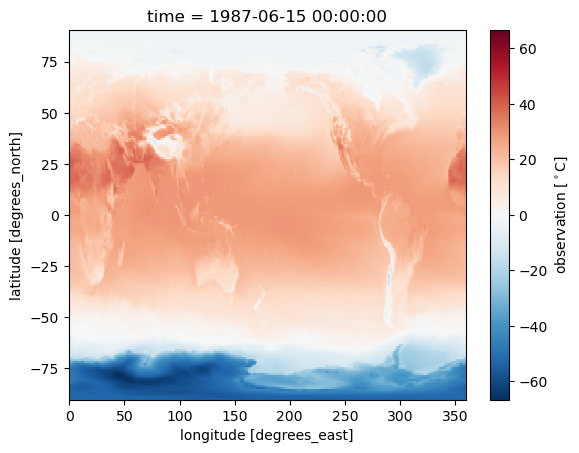

In [13]:
obs_seas_rg.isel(time=min(100, obs_seas_rg.sizes["time"] - 1)).plot()


# Skill Analysis

In [14]:
%%time
time_by_case_month = {
    case_key: {
        init_month: e3sm_seas_by_case_month[case_key][init_month].time.load()
        for init_month in e3sm_months_to_prepare[case_key]
    }
    for case_key in E3SM_CASES
}

# Backward-compatible convenience variables for exploratory cells.
time_by_month = time_by_case_month.get(E3SM_REFERENCE_CASE, {})
e3smle05_time = time_by_month.get(5)
e3smle11_time = time_by_month.get(11)



CPU times: user 11 μs, sys: 6 μs, total: 17 μs
Wall time: 22.2 μs


In [15]:
%%time
# Load or create versioned, analysis-ready E3SM anomaly bundles.

prepared_reuse = prepared_mode != "rebuild"
prepared_skill_datasets = []
anom_by_case_month = {}
clim_by_case_month = {}

for case_key, case_info in E3SM_CASES.items():
    anom_by_case_month[case_key] = {}
    clim_by_case_month[case_key] = {}

    for init_month in init_months:
        prepared_source = case_info["cache_tag"]
        prepared_path, expected_attrs = prepared_specs_by_case_month[case_key][init_month]

        cache_compatible, _ = prepared_skill_cache_status(
            prepared_path, expected_attrs=expected_attrs
        )
        if prepared_reuse and cache_compatible and not prepared_force_recompute:
            print(f"Loading prepared E3SM input: {prepared_path}")
            prepared = open_prepared_skill_dataset(
                prepared_path, expected_attrs=expected_attrs, chunks=prepared_chunks
            )
        else:
            print(f"Creating prepared E3SM input: {prepared_path}")
            anomaly, climatology = stats.remove_drift(
                e3sm_da_by_case_month[case_key][init_month],
                time_by_case_month[case_key][init_month],
                climy0,
                climy1,
            )
            prepared = build_prepared_skill_dataset(
                anomaly,
                climatology,
                time_by_case_month[case_key][init_month],
                source=prepared_source,
                component=analysis_component,
                variable=field,
                init_month=init_month,
                climatology_years=(climy0, climy1),
                source_data_identity=expected_attrs["source_data_identity"],
                case_prefix=expected_attrs["case_prefix"],
                requested_years=INIT_YEARS_BY_MONTH[init_month],
                target_grid=expected_attrs["target_grid"],
                regridding_method=expected_attrs["regridding_method"],
                ensemble_member_count=expected_attrs["ensemble_member_count"],
                lead_count=expected_attrs["lead_count"],
                unit_conversion_version=expected_attrs["unit_conversion_version"],
            )
            write_prepared_skill_dataset(prepared, prepared_path)
            prepared = open_prepared_skill_dataset(
                prepared_path, expected_attrs=expected_attrs, chunks=prepared_chunks
            )

        prepared_skill_datasets.append(prepared)
        workflow_resources.track(prepared)
        anomaly = prepared["anomaly"]
        anom_by_case_month[case_key][init_month] = anomaly
        clim_by_case_month[case_key][init_month] = prepared["climatology"]
        time_by_case_month[case_key][init_month] = prepared["time"].load()

# Backward-compatible convenience variables for exploratory cells.
anom_by_month = anom_by_case_month[E3SM_REFERENCE_CASE]
clim_by_month = clim_by_case_month[E3SM_REFERENCE_CASE]
e3smle05_anom = anom_by_month.get(5)
e3smle11_anom = anom_by_month.get(11)
e3smle05_clim = clim_by_month.get(5)
e3smle11_clim = clim_by_month.get(11)

Loading prepared E3SM input: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/prepared_skill/atm/TS/JRA55_FOSIRL_05_TS_seasonal_anomaly_y1980-2011_ny32_clim_1981_2010_m10_l8_1783c8cd05f5.nc


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/prepared_skill.py:340: UserWarning: The specified chunks separate the stored chunks along dimension "Y" starting at index 3. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/prepared_skill.py:340: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/prepared_skill.py:340: UserWarning: The specified chunks separate the stored chunks along dimension "M" starting at index 2. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/prepared_skill.py:340: UserWarning: The specif

Loading prepared E3SM input: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/prepared_skill/atm/TS/JRA55_FOSIRL_11_TS_seasonal_anomaly_y1980-2011_ny32_clim_1981_2010_m10_l8_b1445717943c.nc
Loading prepared E3SM input: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/leadtime_acc/prepared_skill/atm/TS/Reanalysis_05_TS_seasonal_anomaly_y1980-2011_ny32_clim_1981_2010_m10_l8_21886faa5587.nc


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/prepared_skill.py:340: UserWarning: The specified chunks separate the stored chunks along dimension "Y" starting at index 3. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/prepared_skill.py:340: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/prepared_skill.py:340: UserWarning: The specified chunks separate the stored chunks along dimension "M" starting at index 2. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/prepared_skill.py:340: UserWarning: The specif

Loading prepared E3SM input: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/leadtime_acc/prepared_skill/atm/TS/Reanalysis_11_TS_seasonal_anomaly_y1980-2011_ny32_clim_1981_2010_m10_l8_fde659b23b90.nc
Loading prepared E3SM input: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/leadtime_acc/prepared_skill/atm/TS/4DEnVarOcn_05_TS_seasonal_anomaly_y1980-2011_ny32_clim_1981_2010_m10_l8_980755229a4b.nc


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/prepared_skill.py:340: UserWarning: The specified chunks separate the stored chunks along dimension "Y" starting at index 3. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/prepared_skill.py:340: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/prepared_skill.py:340: UserWarning: The specified chunks separate the stored chunks along dimension "M" starting at index 2. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/prepared_skill.py:340: UserWarning: The specif

Loading prepared E3SM input: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/leadtime_acc/prepared_skill/atm/TS/4DEnVarOcn_11_TS_seasonal_anomaly_y1980-2011_ny32_clim_1981_2010_m10_l8_1fdc9122bf55.nc
CPU times: user 561 ms, sys: 158 ms, total: 719 ms
Wall time: 1.17 s


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/prepared_skill.py:340: UserWarning: The specified chunks separate the stored chunks along dimension "Y" starting at index 3. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/prepared_skill.py:340: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/prepared_skill.py:340: UserWarning: The specified chunks separate the stored chunks along dimension "M" starting at index 2. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/prepared_skill.py:340: UserWarning: The specif

In [16]:
%%time
# Load or create versioned, analysis-ready CESM-SMYLE anomaly bundles.
smyle_time_by_month = {
    init_month: smyle_seas_by_month[init_month].time.load()
    for init_month in smyle_months_to_prepare
}

smyle_anom_by_month = {}
smyle_clim_by_month = {}

for init_month in init_months:
    prepared_path, expected_attrs = smyle_prepared_specs_by_month[init_month]

    cache_compatible, _ = prepared_skill_cache_status(
        prepared_path, expected_attrs=expected_attrs
    )
    if prepared_reuse and cache_compatible and not prepared_force_recompute:
        print(f"Loading prepared CESM-SMYLE input: {prepared_path}")
        prepared = open_prepared_skill_dataset(
            prepared_path, expected_attrs=expected_attrs, chunks=prepared_chunks
        )
    else:
        print(f"Creating prepared CESM-SMYLE input: {prepared_path}")
        anomaly, climatology = stats.remove_drift(
            smyle_da_by_month[init_month],
            smyle_time_by_month[init_month],
            climy0,
            climy1,
        )
        prepared = build_prepared_skill_dataset(
            anomaly,
            climatology,
            smyle_time_by_month[init_month],
            source="CESM-SMYLE",
            component=analysis_component,
            variable=field,
            init_month=init_month,
            climatology_years=(climy0, climy1),
            source_data_identity=expected_attrs["source_data_identity"],
            case_prefix=expected_attrs["case_prefix"],
            requested_years=INIT_YEARS_BY_MONTH[init_month],
            target_grid=expected_attrs["target_grid"],
            regridding_method=expected_attrs["regridding_method"],
            ensemble_member_count=expected_attrs["ensemble_member_count"],
            lead_count=expected_attrs["lead_count"],
            unit_conversion_version=expected_attrs["unit_conversion_version"],
        )
        write_prepared_skill_dataset(prepared, prepared_path)
        prepared = open_prepared_skill_dataset(
            prepared_path, expected_attrs=expected_attrs, chunks=prepared_chunks
        )

    prepared_skill_datasets.append(prepared)
    workflow_resources.track(prepared)
    anomaly = prepared["anomaly"]
    smyle_anom_by_month[init_month] = anomaly
    smyle_clim_by_month[init_month] = prepared["climatology"]
    smyle_time_by_month[init_month] = prepared["time"].load()

smyle05_time = smyle_time_by_month.get(5)
smyle11_time = smyle_time_by_month.get(11)
smyle05_anom = smyle_anom_by_month.get(5)
smyle11_anom = smyle_anom_by_month.get(11)
smyle05_clim = smyle_clim_by_month.get(5)
smyle11_clim = smyle_clim_by_month.get(11)

# Apply the common domain only after all unmasked prepared bundles are open.
# Its actual values and coordinates enter downstream cache provenance.
analysis_domain_identity = "all_surface_v1"
if cfg.get("ocean_only", False):
    samples = [
        anom_by_case_month[case_key][month].isel(Y=0, M=0, L=0, drop=True).notnull()
        for case_key in E3SM_CASES for month in init_months
    ]
    samples = xr.align(*samples, join="exact")
    ocean_mask = xr.concat(samples, dim="mask_source").all("mask_source").compute()
    analysis_domain_identity = ocean_mask_identity(ocean_mask)
    obs_seas_rg = obs_seas_rg.where(ocean_mask)
    for case_key in E3SM_CASES:
        for month in init_months:
            anom_by_case_month[case_key][month] = anom_by_case_month[case_key][month].where(ocean_mask)
    for month in init_months:
        smyle_anom_by_month[month] = smyle_anom_by_month[month].where(ocean_mask)
    print(f"Common ocean domain retains {int(ocean_mask.sum())}/{ocean_mask.size} cells")

# Refresh aliases after applying the analysis domain.
anom_by_month = anom_by_case_month[E3SM_REFERENCE_CASE]
e3smle05_anom, e3smle11_anom = anom_by_month.get(5), anom_by_month.get(11)
smyle05_anom, smyle11_anom = smyle_anom_by_month.get(5), smyle_anom_by_month.get(11)

# Backward-compatible aliases for older exploratory cells.
if cfg["obs_name"] == "ERA5":
    obs_era5_seas_rg = obs_seas_rg
if field == "PRECT":
    obs_gpcp_seas_rg = obs_seas_rg


Loading prepared CESM-SMYLE input: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/prepared_skill/atm/TS/CESM_SMYLE_05_TS_seasonal_anomaly_y1980-2011_ny32_clim_1981_2010_m20_l8_57308aee519d.nc
Loading prepared CESM-SMYLE input: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/prepared_skill/atm/TS/CESM_SMYLE_11_TS_seasonal_anomaly_y1980-2011_ny32_clim_1981_2010_m20_l8_0ec5ece9f467.nc


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/prepared_skill.py:340: UserWarning: The specified chunks separate the stored chunks along dimension "Y" starting at index 3. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/prepared_skill.py:340: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/prepared_skill.py:340: UserWarning: The specified chunks separate the stored chunks along dimension "M" starting at index 2. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/prepared_skill.py:340: UserWarning: The specif

CPU times: user 169 ms, sys: 73.7 ms, total: 243 ms
Wall time: 344 ms


In [17]:
# Optional lightweight sanity check for drift removal.
# The full anomaly arrays are large, so this cell is disabled by default.

if WORKFLOW_SETTINGS["diagnostics"].get("run_drift_check", False):
    drift_check_sample = WORKFLOW_SETTINGS["diagnostics"].get("drift_check_sample", {})
    for case_key in E3SM_CASES:
        for init_month in init_months:
            if init_month not in e3sm_da_by_case_month.get(case_key, {}):
                print(
                    f"Skipping independent drift check for cached {case_key}, month {init_month:02d}; "
                    "use prepared_skill.mode='rebuild' to check against source data."
                )
                continue
            diagnostic_data = e3sm_da_by_case_month[case_key][init_month]
            diagnostic_clim = clim_by_case_month[case_key][init_month]
            if cfg.get("ocean_only", False):
                diagnostic_data = diagnostic_data.where(ocean_mask)
                diagnostic_clim = diagnostic_clim.where(ocean_mask)
            check_remove_drift_sample(
                diagnostic_data,
                time_by_case_month[case_key][init_month],
                anom_by_case_month[case_key][init_month],
                diagnostic_clim,
                climy0,
                climy1,
                drift_check_sample,
                f"{case_key}, init_month={init_month}",
            )
else:
    print("Skipping optional drift-removal diagnostic; set WORKFLOW_SETTINGS['diagnostics']['run_drift_check'] = True to run a sampled check.")


Skipping optional drift-removal diagnostic; set WORKFLOW_SETTINGS['diagnostics']['run_drift_check'] = True to run a sampled check.


In [18]:
%%time
# Compute and save E3SM skill data separately for each case/init month.
# Files are stored under <case>/leadtime_acc/skill/<component>/<field>/.
e3smle_skill_dir = None

# False reuses existing skill NetCDF files; set True only for intentional regeneration.
force_compute = WORKFLOW_SETTINGS["skill"]["force_compute"]
detrend = WORKFLOW_SETTINGS["skill"]["detrend"]
skill_chunk_model = dict(WORKFLOW_SETTINGS["skill"]["model_chunks"])
skill_chunk_obs = dict(WORKFLOW_SETTINGS["skill"]["obs_chunks"])
skill_lead_start = WORKFLOW_SETTINGS["skill"]["lead_start"]
skill_lead_end = WORKFLOW_SETTINGS["skill"]["lead_end"]

clim_start = cftime.DatetimeNoLeap(climy0, 1, 1)
clim_end = cftime.DatetimeNoLeap(climy1, 12, 31)
skill_required_variables = (
    "corr", "pval", "rmse", "msss", "rpc",
    "sig_obs", "sig_sig", "sig_tot", "s2t",
)

# Include the applied analysis domain in every downstream result identity.
skill_observation_identity = source_fingerprint(
    {"observation_data_identity": observation_data_identity,
     "analysis_domain_identity": analysis_domain_identity},
    source_revision="leadtime_acc_domain_v1",
)
skill_cache_common = {
    "variable": field,
    "climatology_years": (climy0, climy1),
    "observation_product": obs_name,
    "observation_variable": obs_var,
    "observation_data_identity": skill_observation_identity,
    "target_grid": target_grid_identity,
    "regridding_method": regrid_method,
    "lead_start": skill_lead_start,
    "lead_end": skill_lead_end,
    "detrend": detrend,
    "unit_conversion_version": UNIT_CONVERSION_VERSION,
}

skill_by_case_month = {}
obs_skill = obs_seas_rg.chunk(skill_chunk_obs)

for case_key, case_info in E3SM_CASES.items():
    cache_tag = case_info["cache_tag"]
    skill_dir = e3sm_leadtime_dir(case_info, "skill", field)
    skill_dir.mkdir(parents=True, exist_ok=True)
    skill_by_case_month[case_key] = {}

    for init_month in init_months:
        verification_years = anom_by_case_month[case_key][init_month].Y.values
        year_token = verification_year_token(verification_years)
        prepared_expected = prepared_specs_by_case_month[case_key][init_month][1]
        expected_skill_attrs = expected_skill_cache_attrs(
            source=cache_tag, case_prefix=case_info["case_prefix"],
            source_data_identity=prepared_expected["source_data_identity"],
            init_month=init_month, verification_years=verification_years,
            ensemble_member_count=anom_by_case_month[case_key][init_month].sizes["M"],
            **skill_cache_common,
        )
        if detrend:
            outname = f"{cache_tag}{init_month:02d}_{field}_skill_{year_token}_clim_{climy0}_{climy1}_l{skill_lead_start}-{skill_lead_end}_detrend.nc"
        else:
            outname = f"{cache_tag}{init_month:02d}_{field}_skill_{year_token}_clim_{climy0}_{climy1}_l{skill_lead_start}-{skill_lead_end}.nc"

        outfile = skill_dir / outname

        cache_compatible, cache_reason = cache_status(
            outfile, expected_attrs=expected_skill_attrs,
            required_variables=skill_required_variables,
        )
        if cache_compatible and not force_compute:
            skill_ds = load_netcdf(outfile)
        else:
            if os.path.exists(outfile) and not force_compute:
                print(f"Ignoring incompatible skill cache {outfile}: {cache_reason}")
            model_anom = anom_by_case_month[case_key][init_month].chunk(skill_chunk_model)
            model_time = time_by_case_month[case_key][init_month]

            skill = compute_skill_lead_range(
                model_anom,
                model_time,
                obs_skill,
                clim_start,
                clim_end,
                skill_lead_start,
                skill_lead_end,
                resamp=0,
                detrend=detrend,
            )

            skill_ds = skill.assign_attrs(expected_skill_attrs).compute()

            atomic_to_netcdf(skill_ds, outfile, **netcdf_write_options)

        skill_by_case_month[case_key][init_month] = skill_ds

        print(outfile)
        print(skill_ds)

# Backward-compatible aliases.
skill_by_month = skill_by_case_month[E3SM_REFERENCE_CASE]
skill05_ds = skill_by_month.get(5)
skill11_ds = skill_by_month.get(11)

/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/skill/atm/TS/JRA55_FOSIRL05_TS_skill_y1980-2011_ny32_clim_1981_2010_l1-8_detrend.nc
<xarray.Dataset> Size: 39MB
Dimensions:             (L: 8, lat: 181, lon: 360)
Coordinates:
  * L                   (L) int64 64B 3 6 9 12 15 18 21 24
  * lat                 (lat) float64 1kB -90.0 -89.0 -88.0 ... 88.0 89.0 90.0
  * lon                 (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
Data variables: (12/13)
    corr                (L, lat, lon) float64 4MB 0.1113 0.1291 ... nan nan
    pval                (L, lat, lon) float64 4MB 0.5441 0.4812 ... nan nan
    rmse                (L, lat, lon) float64 4MB 1.027 1.021 1.021 ... nan nan
    msss                (L, lat, lon) float64 4MB -0.05558 -0.04166 ... nan nan
    rpc                 (L, lat, lon) float64 4MB 0.2991 0.3501 ... nan nan
    sig_obs             (L, lat, lon) float64 4MB 1.296 1.295 ... 1.825 1.826
    ...                  ...
    sig_tot            

In [19]:
%%time
# Compute and save CESM-SMYLE benchmark skill with the same observations/settings.
# Files are stored under CESM-SMYLE/leadtime_acc/skill/<component>/<field>/.
smyle_skill_outdir = smyle_leadtime_dir("skill", field)
os.makedirs(smyle_skill_outdir, exist_ok=True)

smyle_skill_by_month = {}
smyle_overlap_skill_by_month = {}
obs_skill = obs_skill.chunk(skill_chunk_obs)

for init_month in init_months:
    # Initialization months can have different valid-year coordinates.
    # Build the overlap independently for each month so every selected Y
    # value exists in the anomaly, time, and E3SM reference arrays.
    common_years = np.intersect1d(
        smyle_anom_by_month[init_month].Y.values,
        smyle_time_by_month[init_month].Y.values,
    )
    common_years = np.intersect1d(
        common_years,
        anom_by_case_month[E3SM_REFERENCE_CASE][init_month].Y.values,
    )
    full_years = smyle_anom_by_month[init_month].Y.values
    full_year_token = verification_year_token(full_years)
    overlap_year_token = verification_year_token(common_years)
    smyle_prepared_expected = smyle_prepared_specs_by_month[init_month][1]
    expected_full_attrs = expected_skill_cache_attrs(
        source="CESM-SMYLE", case_prefix=smyle_prepared_expected["case_prefix"],
        source_data_identity=smyle_prepared_expected["source_data_identity"],
        init_month=init_month, verification_years=full_years,
        ensemble_member_count=smyle_anom_by_month[init_month].sizes["M"],
        cache_kind="skill_full_record", **skill_cache_common,
    )
    expected_overlap_attrs = expected_skill_cache_attrs(
        source="CESM-SMYLE", case_prefix=smyle_prepared_expected["case_prefix"],
        source_data_identity=smyle_prepared_expected["source_data_identity"],
        init_month=init_month, verification_years=common_years,
        ensemble_member_count=smyle_anom_by_month[init_month].sizes["M"],
        cache_kind="skill_e3sm_overlap", **skill_cache_common,
    )

    if detrend:
        outname = f"BSMYLE{init_month:02d}_{field}_skill_{full_year_token}_clim_{climy0}_{climy1}_l{skill_lead_start}-{skill_lead_end}_detrend.nc"
        outname_overlap = f"BSMYLE{init_month:02d}_{field}_skill_{overlap_year_token}_clim_{climy0}_{climy1}_l{skill_lead_start}-{skill_lead_end}_overlap_detrend.nc"
    else:
        outname = f"BSMYLE{init_month:02d}_{field}_skill_{full_year_token}_clim_{climy0}_{climy1}_l{skill_lead_start}-{skill_lead_end}.nc"
        outname_overlap = f"BSMYLE{init_month:02d}_{field}_skill_{overlap_year_token}_clim_{climy0}_{climy1}_l{skill_lead_start}-{skill_lead_end}_overlap.nc"

    outfile = os.path.join(smyle_skill_outdir, outname)
    outfile_overlap = os.path.join(smyle_skill_outdir, outname_overlap)

    # 1. Full 50-year CESM-SMYLE skill
    full_compatible, full_reason = cache_status(
        outfile, expected_attrs=expected_full_attrs,
        required_variables=skill_required_variables,
    )
    if full_compatible and not force_compute:
        skill_ds = load_netcdf(outfile)
    else:
        if os.path.exists(outfile) and not force_compute:
            print(f"Ignoring incompatible skill cache {outfile}: {full_reason}")
        model_anom = smyle_anom_by_month[init_month].chunk(skill_chunk_model)
        model_time = smyle_time_by_month[init_month]

        skill = compute_skill_lead_range(
            model_anom,
            model_time,
            obs_skill,
            clim_start,
            clim_end,
            skill_lead_start,
            skill_lead_end,
            resamp=0,
            detrend=detrend,
        )

        skill_ds = skill.assign_attrs(expected_full_attrs).compute()

        atomic_to_netcdf(skill_ds, outfile, **netcdf_write_options)

    smyle_skill_by_month[init_month] = skill_ds

    # 2. Common overlap years (39-year) CESM-SMYLE skill
    overlap_compatible, overlap_reason = cache_status(
        outfile_overlap, expected_attrs=expected_overlap_attrs,
        required_variables=skill_required_variables,
    )
    if overlap_compatible and not force_compute:
        skill_ds_overlap = load_netcdf(outfile_overlap)
    else:
        if os.path.exists(outfile_overlap) and not force_compute:
            print(f"Ignoring incompatible skill cache {outfile_overlap}: {overlap_reason}")
        model_anom_ov = smyle_anom_by_month[init_month].sel(Y=common_years).chunk(skill_chunk_model)
        model_time_ov = smyle_time_by_month[init_month].sel(Y=common_years)

        skill_ov = compute_skill_lead_range(
            model_anom_ov,
            model_time_ov,
            obs_skill,
            clim_start,
            clim_end,
            skill_lead_start,
            skill_lead_end,
            resamp=0,
            detrend=detrend,
        )

        skill_ds_overlap = skill_ov.assign_attrs(expected_overlap_attrs).compute()

        atomic_to_netcdf(skill_ds_overlap, outfile_overlap, **netcdf_write_options)

    smyle_overlap_skill_by_month[init_month] = skill_ds_overlap

smyle05_skill_ds = smyle_skill_by_month.get(5)
smyle11_skill_ds = smyle_skill_by_month.get(11)

skill_delta_by_case_month = {
    case_key: {
        init_month: skill_by_case_month[case_key][init_month].corr - smyle_overlap_skill_by_month[init_month].corr
        for init_month in init_months
    }
    for case_key in E3SM_CASES
}

skill_delta_by_month = skill_delta_by_case_month[E3SM_REFERENCE_CASE]



CPU times: user 239 ms, sys: 248 ms, total: 486 ms
Wall time: 1.1 s


### Final ACC Plot: BSMYLE vs E3SMLE (Common Overlap Years)
- Uses the common verification years derived independently for every initialization month and E3SM case.
- Plots each initialization month as paired columns: CESM-SMYLE on the left, E3SMLE on the right.
- Ensures 100% baseline ACC shading alignment with the subsequent significance figure.



In [20]:
%%time
# Read saved CESM-SMYLE and multi-case E3SM skill data and plot side by side.
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from matplotlib.offsetbox import AnchoredText

from esp_lab.utils import mapplot_utils as maps
from esp_lab.utils import mov_utils as mov
from esp_lab.utils.filename_utils import figure_filename

make_pre_significance_acc_plot = WORKFLOW_SETTINGS.get("diagnostics", {}).get(
    "make_pre_significance_acc_plot",
    False,
)

if not make_pre_significance_acc_plot:
    print(
        "Skipping pre-significance ACC overview plot; set "
        "WORKFLOW_SETTINGS['diagnostics']['make_pre_significance_acc_plot'] = True to run it."
    )
else:
    # This plot cell intentionally consumes the single field/configuration selected
    # in the variable-driven setup cell above. Do not silently fall back to another
    # field here; that can mix cached products from different diagnostics.
    _required_setup_names = [
        "field",
        "cfg",
        "init_months",
        "climy0",
        "climy1",
        "detrend",
        "E3SM_CASES",
        "E3SM_REFERENCE_CASE",
        "smyle_overlap_skill_by_month",
        "skill_by_case_month",
    ]
    _missing_setup_names = [name for name in _required_setup_names if name not in globals()]
    if _missing_setup_names:
        raise RuntimeError(
            "Run the variable-driven setup cell before this final ACC plotting cell; "
            f"missing: {_missing_setup_names}"
        )
    FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)

    # ---------------------------------------------------------------------------
    # User-adjustable final-plot setup
    # ---------------------------------------------------------------------------
    metric = "ACC"

    model_order = ["CESM-SMYLE"] + list(E3SM_CASES)
    model_display_name = {"CESM-SMYLE": "CESM-SMYLE"}
    model_display_name.update({
        case_key: case_info.get("display_name", case_key)
        for case_key, case_info in E3SM_CASES.items()
    })
    # Seasonal lead denotes the first monthly lead in each 3-month window:
    # lead 1 = months 1-3, lead 4 = months 4-6, etc.
    max_plot_leads = WORKFLOW_SETTINGS["final_acc_figures"]["max_leads"]
    init_month_names = {
        1: "JAN", 2: "FEB", 3: "MAR", 4: "APR", 5: "MAY", 6: "JUN",
        7: "JUL", 8: "AUG", 9: "SEP", 10: "OCT", 11: "NOV", 12: "DEC",
    }

    sigon = True
    siglvl = 0.1
    mask_negacc = False

    # Single font-size control for the full multi-panel figure.
    fontz = 20
    panel_title_size = fontz
    lead_label_size = fontz * 0.85
    lat_lon_label_size = fontz * 0.8
    colorbar_label_size = fontz
    colorbar_tick_size = fontz * 0.85
    suptitle_size = fontz * 1.15
    fweight = 'bold'

    # Plot style/layout controls.
    figfmt = "png"
    plot_diag_cfg = WORKFLOW_SETTINGS.get("diagnostics", {})
    fig_col_width = 5.0
    fig_row_height = 3.0
    projection = ccrs.PlateCarree()
    suptitle_y = 0.995
    tight_layout_rect = [0, 0.16, 1, 0.985]
    bottom = 0.10
    wspace = 0.05
    save_bbox = "tight"

    cmap = "blue2red_acc"
    coff = 0.5
    ci = 0.1
    cmin = -1
    cmax = 1

    colorbar_axes = [0.25, 0.055, 0.5, 0.02]
    colorbar_orientation = 'horizontal'
    dpi = plot_diag_cfg.get("pre_significance_acc_dpi", 150)
    show_figure_inline = plot_diag_cfg.get("show_pre_significance_acc_plot", False)

    lon_ticks = [-160, -80, 0, 80, 160]
    lat_ticks = [-60, -30, 0, 30, 60]
    lat_lon_tick_length = 2.5
    lat_lon_tick_width = 0.5
    map_axis_linewidth = 1.0
    gridline_width = 0.35
    gridline_color = "0.35"
    gridline_alpha = 0.35
    gridline_style = "-"

    lead_label_loc = "lower right"
    lead_label_pad = 0.25
    lead_label_borderpad = 0.35
    lead_label_bbox = dict(facecolor=(1, 1, 1, 0.72), edgecolor='black', linewidth=0.3, boxstyle='round,pad=0.1')

    skill_by_model = {model: {} for model in model_order}

    for init_month in init_months:
        skill_by_model["CESM-SMYLE"][init_month] = smyle_overlap_skill_by_month[init_month]
        for case_key in E3SM_CASES:
            skill_by_model[case_key][init_month] = skill_by_case_month[case_key][init_month]

    # Keep the old variable names available for exploratory cells below/above.
    skill_by_case_month = {
        case_key: skill_by_model[case_key]
        for case_key in E3SM_CASES
    }
    skill_by_month = skill_by_model[E3SM_REFERENCE_CASE]

    def lead_label(init_month, lead):
        return f"{lead:2d}: {seasonal_label(init_month, lead)}"


    def add_lead_label(ax, text):
        label = AnchoredText(
            text,
            loc=lead_label_loc,
            prop=dict(size=lead_label_size, weight=fweight, family="monospace"),
            frameon=True,
            pad=lead_label_pad,
            borderpad=lead_label_borderpad,
        )
        label.patch.set(**lead_label_bbox)
        ax.add_artist(label)


    def set_map_axis_linewidth(ax):
        for spine in ax.spines.values():
            spine.set_linewidth(map_axis_linewidth)
        if hasattr(ax, "outline_patch"):
            ax.outline_patch.set_linewidth(map_axis_linewidth)


    def add_lat_lon_labels(ax, row, col, nrows, ncols):
        # Keep labels on the outer edges so the multi-panel plot stays readable.
        set_map_axis_linewidth(ax)
        ax.set_xticks(lon_ticks, crs=projection)
        ax.set_yticks(lat_ticks, crs=projection)
        ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(
            labelsize=lat_lon_label_size,
            length=lat_lon_tick_length,
            width=lat_lon_tick_width,
            top=False,
            right=False,
            labelbottom=(row == nrows - 1),
            labelleft=(col == 0),
        )
        ax.gridlines(
            crs=projection,
            linewidth=gridline_width,
            color=gridline_color,
            alpha=gridline_alpha,
            linestyle=gridline_style,
            draw_labels=False,
        )

    skill_plot_by_model = {
        model: {
            init_month: ds.assign_coords(L=ds.L - 2)
            for init_month, ds in by_month.items()
        }
        for model, by_month in skill_by_model.items()
    }

    plot_months = [
        init_month for init_month in init_months
        if all(init_month in skill_plot_by_model[model] for model in model_order)
    ]
    plot_leads = [
        lead for lead in next(iter(skill_plot_by_model[model_order[0]].values())).L.values
        if all(
            lead in skill_plot_by_model[model][init_month].L.values
            for model in model_order
            for init_month in plot_months
        )
    ]

    plot_leads = plot_leads[:max_plot_leads]
    if not plot_months or not plot_leads:
        raise RuntimeError("No common initialization months or leads are available for the overview")
    nrows = len(plot_leads)
    ncols = len(plot_months) * len(model_order)

    subtitle = build_plot_subtitle(cfg["plot_name"], WORKFLOW_SETTINGS, detrend)
    if detrend:
        trendstr = "wt_detrend"
    else:
        trendstr = "wo_detrend"

    corr_by_model = {}
    for model in model_order:
        corr_by_model[model] = {}
        for init_month in plot_months:
            skill_plot = skill_plot_by_model[model][init_month]
            if sigon:
                corr = skill_plot.corr.where(skill_plot.pval < siglvl)
                sigstr = "wt_sigmask"
            else:
                corr = skill_plot.corr
                sigstr = "wo_sigmask"

            if mask_negacc:
                corr = corr.where(corr >= 0)

            corr_by_model[model][init_month] = corr

    print("=== Sanity check: data range ===")
    for model in model_order:
        for init_month, corr in corr_by_model[model].items():
            print(
                f"{model} init_month={init_month} corr min/max:",
                float(corr.min(skipna=True)),
                float(corr.max(skipna=True)),
            )

    figname = figure_filename(
        field, figure_verification_token, figure_init_token, figure_trend_token,
        f"leads_{skill_lead_start}-{skill_lead_end}",
        "multi_e3sm", "acc_skill_map", ext=figfmt,
    )

    print(f"working on figure: {figname}")

    fig = plt.figure(figsize=(fig_col_width * ncols, fig_row_height * nrows))
    fig.suptitle(subtitle, fontsize=suptitle_size, fontweight=fweight, y=suptitle_y)
    proj = projection
    cntr = None

    for i, lead in enumerate(plot_leads):
        for j, init_month in enumerate(plot_months):
            for k, model in enumerate(model_order):
                skill_plot = skill_plot_by_model[model][init_month]
                subplot = i * ncols + j * len(model_order) + k + 1
                model_name = model_display_name.get(model, model)
                title = (
                    f"{model_name} ({init_month_names.get(init_month, f'{init_month:02d}')})"
                    if i == 0 else ''
                )
                ax, cntr = maps.map_pcolor_global_subplot(
                    fig,
                    corr_by_model[model][init_month].sel(L=lead),
                    skill_plot.lon,
                    skill_plot.lat,
                    ci, cmin, cmax,
                    title,
                    nrows, ncols, subplot,
                    proj, cmap=cmap, cutoff=coff,
                    fontsize=panel_title_size,
                )
                add_lead_label(ax, lead_label(init_month, lead))
                add_lat_lon_labels(ax, i, j * len(model_order) + k, nrows, ncols)

    fig.tight_layout(rect=tight_layout_rect)
    fig.subplots_adjust(bottom=bottom, wspace=wspace)
    cbar_ax = fig.add_axes(colorbar_axes)
    cbar = fig.colorbar(cntr, cax=cbar_ax, orientation=colorbar_orientation)
    cbar.set_label(metric, fontsize=colorbar_label_size, fontweight=fweight)
    cbar.ax.tick_params(labelsize=colorbar_tick_size)

    figpath = FIGURE_OUTDIR / figname
    mov.save_figure(
        fig, figpath,
        mode="",
        metric="leadtime_acc",
        title=f"Leadtime ACC Skill: {field}",
        caption="ACC skill vs lead month",
        dpi=dpi,
    )
    print("Saved figure:", figpath)
    if show_figure_inline:
        plt.show()
    else:
        plt.close(fig)


=== Sanity check: data range ===
CESM-SMYLE init_month=5 corr min/max: -0.80651678233887 0.9270420813324433
CESM-SMYLE init_month=11 corr min/max: -0.7218470045083223 0.9646224417293577
E3SM-FOSIRL init_month=5 corr min/max: -0.776401479989914 0.9092331536358625
E3SM-FOSIRL init_month=11 corr min/max: -0.7551849068307531 0.9728301812344697
E3SM-Reanalysis init_month=5 corr min/max: -0.6539004782581976 0.9362480617593874
E3SM-Reanalysis init_month=11 corr min/max: -0.680494848672459 0.9758961692177008
E3SM-4DEnVarOcn init_month=5 corr min/max: -0.7970585811586537 0.7469036212141696
E3SM-4DEnVarOcn init_month=11 corr min/max: -0.6772595354034657 0.8680299095854933
working on figure: fig_ts_y1980_2011_ny32_init_05_11_detrend_leads_1_8_multi_e3sm_acc_skill_map.png
Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_ts_y1980_2011_ny32_init_05_11_detrend_leads_1_8_multi_e3sm_acc_skill_map.png
CPU times: user 23.4 s, sys: 3.92 s, total: 27.4 s
Wall time: 26.5 s


### Test significance of CESM-SMYLE vs E3SMLE, accounting for finite ensemble size
- Uses the common verification years for both systems.
- Set `E3SM_COMPARE_CASE_SELECTION` to one case, a list of cases, or `"all"`.
- Following the Yeager et al. method, resamples the larger ensemble down to the size of the smaller ensemble. Here CESM-SMYLE has 20 members and E3SMLE has 10, so CESM-SMYLE is repeatedly sampled at 10 members without replacement.
- Compares the resulting CESM-SMYLE ACC distribution with the full 10-member E3SMLE ACC.


In [ ]:
%%time
# CESM-SMYLE vs each E3SM hindcast ACC significance figure.
#
# Scientific purpose:
# 1. Restrict CESM-SMYLE and E3SM to common verification years.
# 2. Resample the larger CESM-SMYLE ensemble to the E3SM ensemble size.
# 3. Repeat the CESM-SMYLE subsampling N times without replacement.
# 4. Compute accpval = fraction of resampled CESM-SMYLE ACC > fixed E3SM ACC.

compare_cfg = WORKFLOW_SETTINGS["finite_ensemble_compare"]
compare_mode = compare_cfg["mode"]
compare_force_recompute = compare_cfg["force_recompute"]
compare_detrend = compare_cfg["detrend"]
compare_random_seed = compare_cfg["random_seed"]
cache_compare_anomalies = compare_cfg["cache_anomalies"]
persist_compare_inputs = compare_cfg["persist_inputs"]

# Select which configured E3SM hindcasts to compare with CESM-SMYLE.
# Use "all" for every configured case, a string for one case, or a list for many.
E3SM_COMPARE_CASE_SELECTION = compare_cfg["case_selection"]
if E3SM_COMPARE_CASE_SELECTION == "all":
    E3SM_COMPARE_CASES = list(E3SM_CASES)
elif isinstance(E3SM_COMPARE_CASE_SELECTION, str):
    E3SM_COMPARE_CASES = [E3SM_COMPARE_CASE_SELECTION]
else:
    E3SM_COMPARE_CASES = list(E3SM_COMPARE_CASE_SELECTION)

missing_compare_cases = [case_key for case_key in E3SM_COMPARE_CASES if case_key not in E3SM_CASES]
if missing_compare_cases:
    raise ValueError(f"E3SM_COMPARE_CASE_SELECTION includes cases not in E3SM_CASES: {missing_compare_cases}")
if not E3SM_COMPARE_CASES:
    raise ValueError("E3SM_COMPARE_CASE_SELECTION did not resolve to any E3SM cases.")

print(f"E3SM comparison cases: {E3SM_COMPARE_CASES}")

compare_modes = compare_cfg["modes"]
if compare_mode not in compare_modes:
    raise ValueError(f"compare_mode must be one of {list(compare_modes)}")

compare_mode_cfg = compare_modes[compare_mode]
compare_init_months = [m for m in compare_mode_cfg["init_months"] if m in init_months]
compare_iterations = compare_mode_cfg["iterations"]
compare_lead_start = compare_mode_cfg["lead_start"]
compare_lead_end = compare_mode_cfg["lead_end"]

if not compare_init_months:
    raise ValueError("No requested compare_init_months are available in init_months.")

# Dedicated chunks for the significance calculation. Do not reuse the
# earlier skill chunks, which combine all leads into each task.
compare_chunk_model = dict(WORKFLOW_SETTINGS["finite_ensemble_compare"]["model_chunks"])
compare_chunk_obs = dict(WORKFLOW_SETTINGS["finite_ensemble_compare"]["obs_chunks"])
compare_iteration_batch_size = compare_cfg["iteration_batch_size"]

obs_compare = obs_seas_rg.chunk(compare_chunk_obs)

case_cache_tags = {
    case_key: case_info.get("cache_tag", case_key.replace("E3SM-", ""))
    for case_key, case_info in E3SM_CASES.items()
}
comparison_cache_layout = SkillComparisonCacheLayout(
    root=S2D_DIAG_ROOT, component=analysis_component, variable=field,
    climatology_years=(climy0, climy1), detrend=compare_detrend,
    mode=compare_mode, iterations=compare_iterations,
    random_seed=compare_random_seed,
)


smyle_compare_skill_by_case_month = {}
e3sm_compare_skill_by_case_month = {}
accpval_by_case_month = {}
compare_years_by_case_month = {}
compare_ens_size_by_case_month = {}

for case_key in E3SM_COMPARE_CASES:
    smyle_compare_skill_by_case_month[case_key] = {}
    e3sm_compare_skill_by_case_month[case_key] = {}
    accpval_by_case_month[case_key] = {}
    compare_years_by_case_month[case_key] = {}
    compare_ens_size_by_case_month[case_key] = {}

    for compare_init_month in compare_init_months:
        e3sm_compare_member_count = anom_by_case_month[case_key][compare_init_month].sizes["M"]
        smyle_compare_member_count = smyle_anom_by_month[compare_init_month].sizes["M"]

        if smyle_compare_member_count < e3sm_compare_member_count:
            raise ValueError(
                "This comparison expects CESM-SMYLE to be the larger ensemble; "
                f"got SMYLE={smyle_compare_member_count}, {case_key}={e3sm_compare_member_count}."
            )
        compare_ens_size = e3sm_compare_member_count
        compare_ens_size_by_case_month[case_key][compare_init_month] = compare_ens_size

        compare_years = np.intersect1d(
            smyle_anom_by_month[compare_init_month].Y.values,
            anom_by_case_month[case_key][compare_init_month].Y.values,
        )
        compare_years_by_case_month[case_key][compare_init_month] = compare_years
        e3sm_prepared_expected = prepared_specs_by_case_month[case_key][compare_init_month][1]
        smyle_prepared_expected = smyle_prepared_specs_by_month[compare_init_month][1]
        resampling_identity = {
            "field": field,
            "comparison_case": case_key,
            "initialization_month": int(compare_init_month),
            "verification_years": [year_number(year) for year in compare_years],
            "population_member_count": int(smyle_compare_member_count),
            "sample_member_count": int(compare_ens_size),
            "iterations": int(compare_iterations),
            "lead_start": int(compare_lead_start),
            "lead_end": int(compare_lead_end),
            "detrend": bool(compare_detrend),
            "smyle_source_identity": smyle_prepared_expected["source_data_identity"],
            "e3sm_source_identity": e3sm_prepared_expected["source_data_identity"],
        }
        derived_resampling_seed = stable_resampling_seed(
            compare_random_seed, resampling_identity
        )
        generated_member_indices = generate_member_indices(
            population_size=smyle_compare_member_count,
            sample_size=compare_ens_size, iterations=compare_iterations,
            seed=derived_resampling_seed,
        )
        selection_attrs = member_selection_attrs(
            base_seed=compare_random_seed, derived_seed=derived_resampling_seed,
            identity=resampling_identity, member_indices=generated_member_indices,
        )
        selection_attrs["population_member_count"] = int(smyle_compare_member_count)
        comparison_attrs = {
            "comparison_case": case_key,
            "comparison_ensemble_member_count": int(compare_ens_size),
            "resampling_iterations": int(compare_iterations),
            "random_seed": int(compare_random_seed),
            "comparison_mode": compare_mode,
        } | selection_attrs
        comparison_skill_common = dict(
            skill_cache_common, detrend=compare_detrend,
            lead_start=compare_lead_start, lead_end=compare_lead_end,
        )
        expected_e3sm_compare_attrs = expected_skill_cache_attrs(
            source=case_cache_tags[case_key],
            case_prefix=E3SM_CASES[case_key]["case_prefix"],
            source_data_identity=e3sm_prepared_expected["source_data_identity"],
            init_month=compare_init_month, verification_years=compare_years,
            ensemble_member_count=compare_ens_size,
            cache_kind="fixed_ensemble_comparison_skill",
            **comparison_skill_common,
        ) | comparison_attrs
        expected_smyle_compare_attrs = expected_skill_cache_attrs(
            source="CESM-SMYLE",
            case_prefix=smyle_prepared_expected["case_prefix"],
            source_data_identity=smyle_prepared_expected["source_data_identity"],
            init_month=compare_init_month, verification_years=compare_years,
            ensemble_member_count=compare_ens_size,
            cache_kind="resampled_comparison_skill",
            **comparison_skill_common,
        ) | comparison_attrs
        expected_accp_attrs = dict(
            expected_e3sm_compare_attrs, cache_kind="fraction_smyle_gt_e3sm"
        )

        smyle_file, e3sm_file, accp_file = comparison_cache_layout.result_paths(
            case_cache_tags[case_key], compare_init_month, compare_ens_size, compare_years
        )
        member_selection_file = comparison_cache_layout.member_selection_path(smyle_file)
        member_indices_all = load_or_write_member_selection(
            member_selection_file, generated_member_indices, selection_attrs,
            smyle_compare_member_count, force=compare_force_recompute,
            write_options=netcdf_write_options,
        )

        smyle_cache_ok, _ = cache_status(
            smyle_file, expected_attrs=expected_smyle_compare_attrs,
            required_variables=("corr",),
        )
        e3sm_cache_ok, _ = cache_status(
            e3sm_file, expected_attrs=expected_e3sm_compare_attrs,
            required_variables=("corr",),
        )
        accp_cache_ok, _ = cache_status(
            accp_file, expected_attrs=expected_accp_attrs,
            required_variables=("accpval",),
        )
        if (not compare_force_recompute and smyle_cache_ok and e3sm_cache_ok and accp_cache_ok):
            print(f"Loading cached significance results for {case_key}, init_month={compare_init_month}")

            smyle_skill_tmp = load_netcdf(smyle_file)
            e3sm_skill_tmp = load_netcdf(e3sm_file)

            with xr.open_dataset(accp_file) as ds:
                accpval_tmp = ds["accpval"].load()

            # Older caches encoded an all-missing comparison as 0%. Repair
            # only those invalid cells from the already-cached skill arrays;
            # this does not repeat the expensive resampling calculation.
            valid_comparison = (
                smyle_skill_tmp.corr.notnull()
                & e3sm_skill_tmp.corr.notnull()
            ).any("iteration")
            invalid_cached = accpval_tmp.notnull() & ~valid_comparison
            accpval_tmp = accpval_tmp.where(valid_comparison)
            if bool(invalid_cached.any()):
                print(f"Repairing missing-value mask in {accp_file}")
                repaired_accp = accpval_tmp.to_dataset(name="accpval")
                repaired_accp.attrs.update(expected_accp_attrs)
                atomic_to_netcdf(repaired_accp, accp_file, **netcdf_write_options)

        else:
            print(f"Computing significance results for {case_key}, init_month={compare_init_month}")
            print(f"compare_mode       : {compare_mode}")
            print(f"compare_iterations : {compare_iterations}")
            print(f"compare_leads      : {compare_lead_start} to {compare_lead_end}")
            print(f"compare_detrend    : {compare_detrend}")
            print(f"cache anomalies    : {cache_compare_anomalies}")
            print(f"persist inputs     : {persist_compare_inputs}")

            smyle_compare_anom = (
                smyle_anom_by_month[compare_init_month]
                .sel(Y=compare_years)
                .chunk(compare_chunk_model)
            )

            e3sm_compare_anom = (
                anom_by_case_month[case_key][compare_init_month]
                .sel(Y=compare_years)
                .chunk(compare_chunk_model)
            )

            if cache_compare_anomalies:
                smyle_anom_file, e3sm_anom_file = comparison_cache_layout.anomaly_paths(
                    case_cache_tags[case_key], compare_init_month, compare_years
                )

                smyle_compare_anom = cache_comparison_anomaly(
                    smyle_compare_anom,
                    smyle_anom_file,
                    variable="anom",
                    chunks=compare_chunk_model,
                    force=compare_force_recompute,
                    expected_attrs=dict(
                        expected_smyle_compare_attrs, cache_kind="comparison_anomaly"
                    ),
                    resource_tracker=workflow_resources,
                    write_options=netcdf_write_options,
                )

                e3sm_compare_anom = cache_comparison_anomaly(
                    e3sm_compare_anom,
                    e3sm_anom_file,
                    variable="anom",
                    chunks=compare_chunk_model,
                    force=compare_force_recompute,
                    expected_attrs=dict(
                        expected_e3sm_compare_attrs, cache_kind="comparison_anomaly"
                    ),
                    resource_tracker=workflow_resources,
                    write_options=netcdf_write_options,
                )

            elif persist_compare_inputs:
                smyle_compare_anom = smyle_compare_anom.persist()
                e3sm_compare_anom = e3sm_compare_anom.persist()
                wait([smyle_compare_anom, e3sm_compare_anom])

            smyle_compare_time = smyle_time_by_month[compare_init_month].sel(
                Y=compare_years
            )

            e3sm_compare_time = time_by_case_month[case_key][compare_init_month].sel(
                Y=compare_years
            )

            if e3sm_cache_ok and not compare_force_recompute:
                print(f"Loading cached fixed {case_key} comparison skill...")
                e3sm_skill_tmp = load_netcdf(e3sm_file)
            else:
                print(f"Computing fixed {case_key} comparison skill...")
                e3sm_skill_tmp = compute_skill_lead_range(
                    e3sm_compare_anom,
                    e3sm_compare_time,
                    obs_compare,
                    str(climy0),
                    str(climy1),
                    compare_lead_start,
                    compare_lead_end,
                    resamp=0,
                    detrend=compare_detrend,
                ).load()
                e3sm_skill_tmp.attrs.update(expected_e3sm_compare_attrs)
                atomic_to_netcdf(e3sm_skill_tmp, e3sm_file, **netcdf_write_options)

            print("Computing CESM-SMYLE resampled skill distribution...")

            smyle_skill_batches = []
            for batch_start in range(0, compare_iterations, compare_iteration_batch_size):
                batch_stop = min(batch_start + compare_iteration_batch_size, compare_iterations)
                batch_file = comparison_cache_layout.batch_path(
                    smyle_file, batch_start, batch_stop
                )
                expected_batch_attrs = dict(
                    expected_smyle_compare_attrs,
                    cache_kind="resampled_comparison_skill_batch",
                    iteration_batch_start=int(batch_start),
                    iteration_batch_stop=int(batch_stop),
                )
                batch_cache_ok, _ = cache_status(
                    batch_file, expected_attrs=expected_batch_attrs,
                    required_variables=("corr",),
                )
                if batch_cache_ok and not compare_force_recompute:
                    print(f"  loading iterations {batch_start + 1}-{batch_stop}")
                    batch_skill = load_netcdf(batch_file)
                else:
                    print(f"  computing iterations {batch_start + 1}-{batch_stop}")
                    batch_skill = compute_skill_lead_range_batch(
                        smyle_compare_anom,
                        smyle_compare_time,
                        obs_compare,
                        str(climy0),
                        str(climy1),
                        member_indices_all[batch_start:batch_stop],
                        compare_lead_start,
                        compare_lead_end,
                        detrend=compare_detrend,
                        metrics=("corr",),
                    ).load()
                    batch_skill = batch_skill.assign_coords(
                        iteration=np.arange(batch_start, batch_stop)
                    )
                    batch_skill.attrs.update(expected_batch_attrs)
                    atomic_to_netcdf(batch_skill, batch_file, **netcdf_write_options)
                smyle_skill_batches.append(batch_skill)

            smyle_skill_tmp = xr.concat(smyle_skill_batches, dim="iteration")

            print("Computing ACC superiority fraction...")

            accpval_tmp = acc_superiority_fraction(
                smyle_skill_tmp.corr, e3sm_skill_tmp.corr
            ).rename("accpval").load()

            print(f"Writing significance cache for {case_key}, init_month={compare_init_month}")

            smyle_skill_tmp.attrs.update(expected_smyle_compare_attrs)
            accpval_ds = accpval_tmp.to_dataset(name="accpval")
            accpval_ds.attrs.update(expected_accp_attrs)
            atomic_to_netcdf(smyle_skill_tmp, smyle_file, **netcdf_write_options)
            atomic_to_netcdf(accpval_ds, accp_file, **netcdf_write_options)

        smyle_compare_skill_by_case_month[case_key][compare_init_month] = smyle_skill_tmp
        e3sm_compare_skill_by_case_month[case_key][compare_init_month] = e3sm_skill_tmp
        accpval_by_case_month[case_key][compare_init_month] = accpval_tmp

        print("")
        print("case_key:", case_key)
        print("compare_init_month:", compare_init_month)
        print(
            "compare_years:",
            year_number(compare_years[0]),
            year_number(compare_years[-1]),
            "n=",
            compare_years.size,
        )
        print(f"{case_key} members:", e3sm_compare_member_count)
        print("CESM-SMYLE members:", smyle_compare_member_count)
        print("resampled ensemble size:", compare_ens_size)
        print(f"{case_key} fixed-ensemble skill:")
        print(e3sm_skill_tmp)
        print("CESM-SMYLE resampled skill distribution:")
        print(smyle_compare_skill_by_case_month[case_key][compare_init_month])


# Backward-compatible aliases for downstream plotting.
# Prefer November if available; otherwise use the last processed initialization month.
if 11 in compare_init_months:
    compare_init_month = 11
else:
    compare_init_month = compare_init_months[-1]

compare_case = (
    E3SM_REFERENCE_CASE if E3SM_REFERENCE_CASE in E3SM_COMPARE_CASES
    else E3SM_COMPARE_CASES[0]
)
compare_years = compare_years_by_case_month[compare_case][compare_init_month]
smyle_compare_skill_by_month = smyle_compare_skill_by_case_month[compare_case]
e3sm_compare_skill_by_month = e3sm_compare_skill_by_case_month[compare_case]
accpval_by_month = accpval_by_case_month[compare_case]
compare_ens_size_by_month = compare_ens_size_by_case_month[compare_case]
compare_years_by_month = compare_years_by_case_month[compare_case]

smyle_compare_skill = smyle_compare_skill_by_month[compare_init_month]
e3sm_compare_skill = e3sm_compare_skill_by_month[compare_init_month]
accpval = accpval_by_month[compare_init_month]

lon2d, lat2d = np.meshgrid(destgrid.lon, destgrid.lat)



E3SM comparison cases: ['E3SM-FOSIRL', 'E3SM-Reanalysis', 'E3SM-4DEnVarOcn']
Loading deterministic member selections: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/resampling_cache/atm/member_selections/TS/BSMYLE05_TS_clim_1981_2010_resamp_to_JRA55_FOSIRL_skill_detrend_final_n10_iter100_seed42_1980-2011_ny32_member_indices.nc
Loading cached significance results for E3SM-FOSIRL, init_month=5

case_key: E3SM-FOSIRL
compare_init_month: 5
compare_years: 1980 2011 n= 32
E3SM-FOSIRL members: 10
CESM-SMYLE members: 20
resampled ensemble size: 10
E3SM-FOSIRL fixed-ensemble skill:
<xarray.Dataset> Size: 39MB
Dimensions:             (L: 8, lat: 181, lon: 360)
Coordinates:
  * L                   (L) int64 64B 3 6 9 12 15 18 21 24
  * lat                 (lat) float64 1kB -90.0 -89.0 -88.0 ... 88.0 89.0 90.0
  * lon                 (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
Data variables: (12/13)
    corr                (L, lat, lon) float64 4MB 0.1113 0.1291 ... nan

/global/u2/z/zhan391/code/ESP-Lab/esp_lab/leadtime_skill_cache.py:401: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  dataset = resource_tracker.track(xr.open_dataset(path, chunks=chunks))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/leadtime_skill_cache.py:401: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  dataset = resource_tracker.track(xr.open_dataset(path, chunks=chunks))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/leadtime_skill_cache.py:401: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 60. This could degrade performance. Instead, consider rechunking after loading.
  dataset = resource_tracker.track(xr.open_dataset(path, chunks=chunks))


Opening cached anomaly with Dask chunks: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/leadtime_acc/comparison/atm/anomalies/TS/4DEnVarOcn05_TS_clim_1981_2010_compare_anom_detrend_1980-2011_ny32.nc
Loading cached fixed E3SM-4DEnVarOcn comparison skill...


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/leadtime_skill_cache.py:401: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  dataset = resource_tracker.track(xr.open_dataset(path, chunks=chunks))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/leadtime_skill_cache.py:401: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  dataset = resource_tracker.track(xr.open_dataset(path, chunks=chunks))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/leadtime_skill_cache.py:401: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 60. This could degrade performance. Instead, consider rechunking after loading.
  dataset = resource_tracker.track(xr.open_dataset(path, chunks=chunks))


Computing CESM-SMYLE resampled skill distribution...
  loading iterations 1-10
  loading iterations 11-20
  loading iterations 21-30
  loading iterations 31-40
  computing iterations 41-50


In [ ]:
# -----------------------------------------------------------------------------
# Final ACC comparison figure setup
# -----------------------------------------------------------------------------
# Values come from WORKFLOW_SETTINGS["final_acc_figures"].
init_month_names = {
    1: "JAN", 2: "FEB", 3: "MAR", 4: "APR", 5: "MAY", 6: "JUN",
    7: "JUL", 8: "AUG", 9: "SEP", 10: "OCT", 11: "NOV", 12: "DEC",
}

final_acc_cfg = WORKFLOW_SETTINGS["final_acc_figures"]
final_geom_cfg = final_acc_cfg["geometry"]
final_marker_cfg = final_acc_cfg["markers"]
final_acc_style_cfg = final_acc_cfg["acc"]
final_skilldiff_style_cfg = final_acc_cfg["skilldiff"]

compare_init_months_requested = list(final_acc_cfg["init_months"])
compare_plot_max_leads = final_acc_cfg["max_leads"]

# Panel geometry and spacing
compare_fig_col_width = final_geom_cfg["fig_col_width"]
compare_fig_row_height = final_geom_cfg["fig_row_height"]
compare_section_gap = final_geom_cfg["section_gap"]
compare_section_gap_fig_width = final_geom_cfg["section_gap_fig_width"]
compare_tight_layout_rect = list(final_geom_cfg["tight_layout_rect"])
compare_subplots_top = final_geom_cfg["subplots_top"]
compare_subplots_bottom = final_geom_cfg["subplots_bottom"]
compare_subplots_hspace = final_geom_cfg["subplots_hspace"]
compare_subplots_wspace = final_geom_cfg["subplots_wspace"]
compare_month_header_y = final_geom_cfg["month_header_y"]
compare_divider_y0 = final_geom_cfg["divider_y0"]
compare_divider_y1 = final_geom_cfg["divider_y1"]
compare_divider_color = final_geom_cfg["divider_color"]
compare_divider_linewidth = final_geom_cfg["divider_linewidth"]
compare_cbar_rect = list(final_geom_cfg["cbar_rect"])

# Shared map and significance-marker settings
compare_label_bbox = dict(final_marker_cfg["label_bbox"])

# ACC figure contents and styling
acc_include_cesm_smyle = final_acc_style_cfg["include_cesm_smyle"]
acc_cesm_label = final_acc_style_cfg["cesm_label"]
acc_ci = final_acc_style_cfg["ci"]
acc_cmin = final_acc_style_cfg["cmin"]
acc_cmax = final_acc_style_cfg["cmax"]
acc_cmap = final_acc_style_cfg["cmap"]
acc_cutoff = final_acc_style_cfg["cutoff"]
acc_fontz = final_acc_style_cfg["fontz"]
acc_panel_title_size = acc_fontz * 1.2
acc_lead_label_size = acc_fontz * 0.85
acc_lat_lon_label_size = acc_fontz * 0.8
acc_suptitle_size = acc_fontz * 1.25
acc_colorbar_label_size = acc_fontz
acc_colorbar_tick_size = acc_fontz * 0.85
acc_section_label_size = acc_fontz * 1.05

# E3SM minus matched CESM-SMYLE ACC figure styling
skilldiff_ci = final_skilldiff_style_cfg["ci"]
skilldiff_cmin = final_skilldiff_style_cfg["cmin"]
skilldiff_cmax = final_skilldiff_style_cfg["cmax"]
skilldiff_cmap = final_skilldiff_style_cfg["cmap"]
skilldiff_cutoff = final_skilldiff_style_cfg["cutoff"]
skilldiff_fontz = final_skilldiff_style_cfg["fontz"]
skilldiff_panel_title_size = skilldiff_fontz
skilldiff_lat_lon_label_size = skilldiff_fontz * 0.95
skilldiff_suptitle_size = skilldiff_fontz * 0.95
skilldiff_colorbar_label_size = skilldiff_fontz * 0.95
skilldiff_colorbar_tick_size = skilldiff_fontz * 0.90
skilldiff_lead_label_size = skilldiff_fontz * 0.90
skilldiff_section_label_size = skilldiff_fontz * 1.00

compare_fweight = final_acc_cfg["font_weight"]

# Distinguish figures from different lead ranges and resampling configurations.
comparison_figure_token = source_fingerprint(
    {"cases": E3SM_COMPARE_CASES, "months": compare_init_months,
     "lead_start": compare_lead_start, "lead_end": compare_lead_end,
     "iterations": compare_iterations, "seed": compare_random_seed,
     "domain": analysis_domain_identity}, source_revision="acc_figures_v2",
).split(":")[-1][:12]

# Figure titles and save metadata
if detrend != compare_detrend:
    raise ValueError("skill.detrend and finite_ensemble_compare.detrend must match")
trend_label = "linear-detrend" if compare_detrend else "no-detrend"
initialization_label = ", ".join(
    init_month_names.get(month, f"{month:02d}") for month in compare_init_months_requested
)
figure_run_context = (
    f"Verification {lead_years[0]}–{lead_years[-1]}; "
    f"initialization {initialization_label}; climatology {climy0}–{climy1}; "
    f"{trend_label}."
)
acc_figure_title = final_acc_style_cfg["title_template"].format(
    plot_name=cfg["plot_name"], field=field, trend_label=trend_label,
)
acc_save_title = acc_figure_title
acc_save_caption = f"{final_acc_style_cfg['caption']} {figure_run_context}"
skilldiff_figure_title = final_skilldiff_style_cfg["title_template"].format(
    plot_name=cfg["plot_name"], field=field, trend_label=trend_label,
)
skilldiff_save_title = final_skilldiff_style_cfg["save_title_template"].format(plot_name=cfg["plot_name"], field=field)
skilldiff_save_caption = f"{final_skilldiff_style_cfg['caption']} {figure_run_context}"


In [ ]:
%%time
# Plot each selected E3SM hindcast ACC with ensemble-size-matched CESM-SMYLE
# significance markers. The figure columns are grouped by initialization month;
# selected E3SM cases are shown side by side within each month group.
ci = acc_ci
cmin = acc_cmin
cmax = acc_cmax
compare_panel_title_size = acc_panel_title_size
compare_lead_label_size = acc_lead_label_size
compare_lat_lon_label_size = acc_lat_lon_label_size
compare_suptitle_size = acc_suptitle_size
compare_colorbar_label_size = acc_colorbar_label_size
compare_colorbar_tick_size = acc_colorbar_tick_size
compare_section_label_size = acc_section_label_size

compare_init_months_plot = [
    m for m in compare_init_months_requested
    if m in compare_init_months
    and m in smyle_compare_skill_by_case_month[compare_case]
]
if not compare_init_months_plot:
    raise RuntimeError("None of the requested initialization months are available for plotting.")

area = destgrid.area
proj = ccrs.PlateCarree()

column_specs = []
for init_month in compare_init_months_plot:
    if acc_include_cesm_smyle and init_month in smyle_skill_by_month:
        column_specs.append((init_month, "CESM-SMYLE", None))

    for case_key in E3SM_COMPARE_CASES:
        if (
            init_month in smyle_compare_skill_by_case_month.get(case_key, {})
            and init_month in e3sm_compare_skill_by_case_month.get(case_key, {})
            and init_month in accpval_by_case_month.get(case_key, {})
        ):
            column_specs.append((init_month, "E3SM", case_key))

if not column_specs:
    raise RuntimeError("No CESM-SMYLE or E3SM case/month combinations are available for plotting.")


def _acc_skill_for_column(init_month, model_kind, case_key):
    if model_kind == "CESM-SMYLE":
        leads = e3sm_compare_skill_by_case_month[E3SM_COMPARE_CASES[0]][init_month].L
        return smyle_skill_by_month[init_month].sel(L=leads)
    return e3sm_compare_skill_by_case_month[case_key][init_month]


plot_nlead = min(
    compare_plot_max_leads,
    *(
        _acc_skill_for_column(init_month, model_kind, case_key).sizes["L"]
        for init_month, model_kind, case_key in column_specs
    ),
)
nrows = plot_nlead
ncols = len(column_specs)
section_gap = compare_section_gap if len(compare_init_months_plot) > 1 else 0.0
fig = plt.figure(figsize=(compare_fig_col_width * ncols + compare_section_gap_fig_width * (section_gap > 0), compare_fig_row_height * nrows))
cntr = None


for i in range(plot_nlead):
    for col, (compare_init_month, model_kind, case_key) in enumerate(column_specs):
        if model_kind == "CESM-SMYLE":
            case_label = acc_cesm_label
            plot_skill = _acc_skill_for_column(compare_init_month, model_kind, case_key)
            accp = None
        else:
            case_label = E3SM_CASES[case_key].get("display_name", case_key)
            plot_skill = e3sm_compare_skill_by_case_month[case_key][compare_init_month]
            accp = accpval_by_case_month[case_key][compare_init_month]

        init_label = init_month_names.get(compare_init_month, f"{compare_init_month:02d}")
        lead = int(plot_skill.L.values[i])
        display_lead = lead - 2
        leadstr = f"lead {display_lead}: {seasonal_label(compare_init_month, display_lead)}"
        title = f"{case_label}" if i == 0 else ""
        subplot = i * ncols + col + 1

        ax, cntr = maps.map_pcolor_global_subplot(
            fig,
            plot_skill.corr.isel(L=i),
            plot_skill.lon,
            plot_skill.lat,
            ci, cmin, cmax,
            title,
            nrows, ncols, subplot,
            proj, cmap=acc_cmap, cutoff=acc_cutoff,
            fontsize=compare_panel_title_size,
        )
        style_global_map_axis(
            ax, row=i, column=col, nrows=nrows,
            label_size=compare_lat_lon_label_size, style=final_marker_cfg,
        )
        if col == 0 or col == len(column_specs) // 2:
            ax.text(
                0.02, 0.05, leadstr,
                fontsize=compare_lead_label_size,
                fontweight=compare_fweight,
                bbox=compare_label_bbox,
                zorder=10,
                transform=ax.transAxes,
                ha="left", va="bottom",
            )
        if accp is not None:
            add_acc_comparison_markers(
                ax, plot_skill, accp, i, area=area, latitude=destgrid.lat,
                longitude_2d=lon2d, latitude_2d=lat2d, style=final_marker_cfg,
                font_size=compare_lead_label_size, font_weight=compare_fweight,
                label_bbox=compare_label_bbox,
            )

fig.suptitle(
    acc_figure_title,
    fontsize=compare_suptitle_size,
    fontweight=compare_fweight,
    y=0.995,
)
layout_rect = compare_tight_layout_rect.copy()
layout_rect[2] = layout_rect[2] - section_gap
fig.tight_layout(rect=layout_rect)
fig.subplots_adjust(top=compare_subplots_top, bottom=compare_subplots_bottom, hspace=compare_subplots_hspace, wspace=compare_subplots_wspace)

if section_gap:
    second_month_cols = [i for i, (m, _, __) in enumerate(column_specs) if m == compare_init_months_plot[1]]
    second_month_axes = [fig.axes[row * ncols + col] for row in range(nrows) for col in second_month_cols]
    for ax in second_month_axes:
        pos = ax.get_position()
        ax.set_position([pos.x0 + section_gap, pos.y0, pos.width, pos.height])

# Add initialization-month headers above their case columns.
for init_month in compare_init_months_plot:
    cols = [i for i, (m, _, __) in enumerate(column_specs) if m == init_month]
    if not cols:
        continue
    left = min(fig.axes[i].get_position().x0 for i in cols)
    right = max(fig.axes[i].get_position().x1 for i in cols)
    init_label = init_month_names.get(init_month, f"{init_month:02d}")
    fig.text(
        (left + right) / 2,
        compare_month_header_y,
        f"{init_label} initialization",
        ha="center", va="bottom",
        fontsize=compare_section_label_size,
        fontweight=compare_fweight,
    )

if len(compare_init_months_plot) > 1:
    first_month_cols = [i for i, (m, _, __) in enumerate(column_specs) if m == compare_init_months_plot[0]]
    second_month_cols = [i for i, (m, _, __) in enumerate(column_specs) if m == compare_init_months_plot[1]]
    if first_month_cols and second_month_cols:
        divider_x = (
            max(fig.axes[i].get_position().x1 for i in first_month_cols)
            + min(fig.axes[i].get_position().x0 for i in second_month_cols)
        ) / 2
        fig.add_artist(plt.Line2D([divider_x, divider_x], [compare_divider_y0, compare_divider_y1], transform=fig.transFigure, color=compare_divider_color, linewidth=compare_divider_linewidth))

cbar_ax = fig.add_axes(compare_cbar_rect)
cbar = fig.colorbar(cntr, cax=cbar_ax, orientation="horizontal")
cbar.set_label("ACC", fontsize=compare_colorbar_label_size, fontweight=compare_fweight)
cbar.ax.tick_params(labelsize=compare_colorbar_tick_size)

compare_figname = figure_filename(
    field, figure_verification_token, figure_init_token, figure_trend_token, comparison_figure_token,
    "acc_skill_compare",
)
compare_figpath = FIGURE_OUTDIR / compare_figname
mov.save_figure(
    fig, compare_figpath,
    mode="",
    metric="leadtime_acc_compare",
    title=acc_save_title,
    caption=acc_save_caption,
    dpi=300,
)
print("Saved figure:", compare_figpath)
plt.show()


### E3SM ACC With Side-by-Side Case Comparison
- Plots one ACC figure for the selected E3SM cases.
- Set `E3SM_COMPARE_CASE_SELECTION` upstream to one case, multiple cases, or `"all"`.
- Columns are grouped by initialization month: May on the left, November on the right.
- E3SM hindcasts are shown side by side within each month group.


In [ ]:
%%time
# Plot fixed 10-member E3SM ACC minus mean matched-size CESM-SMYLE ACC.
# Columns are grouped by initialization month; selected E3SM cases are shown
# side by side within each month group.
ci = skilldiff_ci
cmin = skilldiff_cmin
cmax = skilldiff_cmax
compare_panel_title_size = skilldiff_panel_title_size
compare_lat_lon_label_size = skilldiff_lat_lon_label_size
compare_suptitle_size = skilldiff_suptitle_size
compare_colorbar_label_size = skilldiff_colorbar_label_size
compare_colorbar_tick_size = skilldiff_colorbar_tick_size
compare_lead_label_size = skilldiff_lead_label_size
compare_section_label_size = skilldiff_section_label_size

compare_init_months_plot = [
    m for m in compare_init_months_requested
    if m in compare_init_months
    and m in smyle_compare_skill_by_case_month[compare_case]
]
if not compare_init_months_plot:
    raise RuntimeError("None of the requested initialization months are available for plotting.")

area = destgrid.area
proj = ccrs.PlateCarree()

e3sm_compare_skilldiff_by_case_month = {
    case_key: {
        m: e3sm_compare_skill_by_case_month[case_key][m]
        - smyle_compare_skill_by_case_month[case_key][m].mean("iteration")
        for m in compare_init_months_plot
        if m in smyle_compare_skill_by_case_month.get(case_key, {})
        and m in e3sm_compare_skill_by_case_month.get(case_key, {})
    }
    for case_key in E3SM_COMPARE_CASES
}

column_specs = []
for init_month in compare_init_months_plot:
    for case_key in E3SM_COMPARE_CASES:
        if (
            init_month in smyle_compare_skill_by_case_month.get(case_key, {})
            and init_month in e3sm_compare_skill_by_case_month.get(case_key, {})
            and init_month in accpval_by_case_month.get(case_key, {})
            and init_month in e3sm_compare_skilldiff_by_case_month.get(case_key, {})
        ):
            column_specs.append((init_month, case_key))

if not column_specs:
    raise RuntimeError("No E3SM case/month combinations are available for plotting.")

plot_nlead = min(
    compare_plot_max_leads,
    *(e3sm_compare_skilldiff_by_case_month[case_key][init_month].sizes["L"] for init_month, case_key in column_specs),
)
nrows = plot_nlead
ncols = len(column_specs)
section_gap = compare_section_gap if len(compare_init_months_plot) > 1 else 0.0
fig = plt.figure(figsize=(compare_fig_col_width * ncols + compare_section_gap_fig_width * (section_gap > 0), compare_fig_row_height * nrows))
cntr = None


for i in range(plot_nlead):
    for col, (compare_init_month, case_key) in enumerate(column_specs):
        case_label = E3SM_CASES[case_key].get("display_name", case_key)
        init_label = init_month_names.get(compare_init_month, f"{compare_init_month:02d}")
        smyle_skill = smyle_compare_skill_by_case_month[case_key][compare_init_month]
        skilldiff = e3sm_compare_skilldiff_by_case_month[case_key][compare_init_month]
        accp = accpval_by_case_month[case_key][compare_init_month]
        lead = int(smyle_skill.L.values[i])
        display_lead = lead - 2
        leadstr = f"lead {display_lead}: {seasonal_label(compare_init_month, display_lead)}"
        title = f"{case_label}" if i == 0 else ""
        subplot = i * ncols + col + 1

        ax, cntr = maps.map_pcolor_global_subplot(
            fig,
            skilldiff.corr.isel(L=i),
            smyle_skill.lon,
            smyle_skill.lat,
            ci, cmin, cmax,
            title,
            nrows, ncols, subplot,
            proj, cmap=skilldiff_cmap, cutoff=skilldiff_cutoff,
            fontsize=compare_panel_title_size,
        )
        style_global_map_axis(
            ax, row=i, column=col, nrows=nrows,
            label_size=compare_lat_lon_label_size, style=final_marker_cfg,
        )
        if col == 0 or col == len(column_specs) // 2:
            ax.text(
                0.02, 0.05, leadstr,
                fontsize=compare_lead_label_size,
                fontweight=compare_fweight,
                bbox=compare_label_bbox,
                zorder=10,
                transform=ax.transAxes,
                ha="left", va="bottom",
            )
        add_acc_comparison_markers(
            ax, skilldiff, accp, i, area=area, latitude=destgrid.lat,
            longitude_2d=lon2d, latitude_2d=lat2d, style=final_marker_cfg,
            font_size=compare_lead_label_size, font_weight=compare_fweight,
            label_bbox=compare_label_bbox,
        )

fig.suptitle(
    skilldiff_figure_title,
    fontsize=compare_suptitle_size,
    fontweight=compare_fweight,
    y=0.995,
)
layout_rect = compare_tight_layout_rect.copy()
layout_rect[2] = layout_rect[2] - section_gap
fig.tight_layout(rect=layout_rect)
fig.subplots_adjust(top=compare_subplots_top, bottom=compare_subplots_bottom, hspace=compare_subplots_hspace, wspace=compare_subplots_wspace)

if section_gap:
    second_month_cols = [i for i, (m, _) in enumerate(column_specs) if m == compare_init_months_plot[1]]
    second_month_axes = [fig.axes[row * ncols + col] for row in range(nrows) for col in second_month_cols]
    for ax in second_month_axes:
        pos = ax.get_position()
        ax.set_position([pos.x0 + section_gap, pos.y0, pos.width, pos.height])

# Add initialization-month headers above their case columns.
for init_month in compare_init_months_plot:
    cols = [i for i, (m, _) in enumerate(column_specs) if m == init_month]
    if not cols:
        continue
    left = min(fig.axes[i].get_position().x0 for i in cols)
    right = max(fig.axes[i].get_position().x1 for i in cols)
    init_label = init_month_names.get(init_month, f"{init_month:02d}")
    fig.text(
        (left + right) / 2,
        compare_month_header_y,
        f"{init_label} initialization",
        ha="center", va="bottom",
        fontsize=compare_section_label_size,
        fontweight=compare_fweight,
    )

if len(compare_init_months_plot) > 1:
    first_month_cols = [i for i, (m, _) in enumerate(column_specs) if m == compare_init_months_plot[0]]
    second_month_cols = [i for i, (m, _) in enumerate(column_specs) if m == compare_init_months_plot[1]]
    if first_month_cols and second_month_cols:
        divider_x = (
            max(fig.axes[i].get_position().x1 for i in first_month_cols)
            + min(fig.axes[i].get_position().x0 for i in second_month_cols)
        ) / 2
        fig.add_artist(plt.Line2D([divider_x, divider_x], [compare_divider_y0, compare_divider_y1], transform=fig.transFigure, color=compare_divider_color, linewidth=compare_divider_linewidth))

cbar_ax = fig.add_axes(compare_cbar_rect)
cbar = fig.colorbar(cntr, cax=cbar_ax, orientation="horizontal")
cbar.set_label(r"${\Delta}$ACC", fontsize=compare_colorbar_label_size, fontweight=compare_fweight)
cbar.ax.tick_params(labelsize=compare_colorbar_tick_size)

skilldiff_figname = figure_filename(
    field, figure_verification_token, figure_init_token, figure_trend_token, comparison_figure_token,
    "acc_skill_diff",
)
skilldiff_figpath = FIGURE_OUTDIR / skilldiff_figname
mov.save_figure(
    fig, skilldiff_figpath,
    mode="",
    metric="leadtime_acc_diff",
    title=skilldiff_save_title,
    caption=skilldiff_save_caption,
    dpi=300,
)
print("Saved figure:", skilldiff_figpath)
plt.show()

# Backward-compatible reference-case difference dictionary.
e3sm_compare_skilldiff_by_month = {
    m: e3sm_compare_skill_by_case_month[compare_case][m]
    - smyle_compare_skill_by_case_month[compare_case][m].mean("iteration")
    for m in compare_init_months_plot
}


### CESM-SMYLE Sample Length Comparison: Full Available Record vs Common E3SM Overlap

- Compares CESM-SMYLE ACC skill over its available record against the common E3SM overlap period.
- Year ranges and sample counts are generated from the loaded dataset coordinates.
- Demonstrates how sample length and decadal variability impact skill scores and gray shading cutoff boundaries.


In [ ]:
%%time
# Plot CESM-SMYLE available record versus common E3SM overlap period.
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs

from esp_lab.utils import mapplot_utils as maps
from esp_lab.utils import mov_utils as mov


def year_label(years):
    years = np.asarray(years)
    if years.size == 0:
        return "no years"
    return f"{year_number(years[0])}–{year_number(years[-1])}, {years.size}yr"


def available_years(init_month):
    return np.intersect1d(
        smyle_anom_by_month[init_month].Y.values,
        smyle_time_by_month[init_month].Y.values,
    )


def overlap_years(init_month):
    return np.intersect1d(
        available_years(init_month),
        anom_by_case_month[E3SM_REFERENCE_CASE][init_month].Y.values,
    )


smyle_records = [
    ("CESM-SMYLE available record", smyle_skill_by_month, available_years),
    ("CESM-SMYLE common E3SM overlap", smyle_overlap_skill_by_month, overlap_years),
]

plot_months = [
    month for month in init_months
    if all(month in record_by_month for _, record_by_month, _ in smyle_records)
]
if not plot_months:
    raise RuntimeError("No CESM-SMYLE initialization months are available")
plot_nlead = min(
    WORKFLOW_SETTINGS["final_acc_figures"]["max_leads"],
    *(record_by_month[month].sizes["L"]
      for _, record_by_month, _ in smyle_records
      for month in plot_months),
)
plot_leads = list(range(plot_nlead))

if not plot_months or not plot_leads:
    raise RuntimeError("No CESM-SMYLE initialization months or leads are available.")

nrows = len(plot_leads)
ncols = len(plot_months) * len(smyle_records)
fig = plt.figure(
    figsize=(
        final_geom_cfg["fig_col_width"] * ncols,
        final_geom_cfg["fig_row_height"] * nrows,
    )
)

first_month = plot_months[0]
fig.suptitle(
    f"CESM-SMYLE {cfg['plot_name']} Skill: "
    f"{year_label(available_years(first_month))} vs "
    f"{year_label(overlap_years(first_month))}",
    fontsize=final_acc_style_cfg["fontz"] * 1.25,
    fontweight="bold",
    y=0.995,
)

proj = ccrs.PlateCarree()
cntr = None

for i, lead_index in enumerate(plot_leads):
    for j, init_month in enumerate(plot_months):
        for k, (record_name, record_by_month, years_function) in enumerate(smyle_records):
            skill_ds = record_by_month[init_month]
            subplot = i * ncols + j * len(smyle_records) + k + 1
            title = (
                f"{record_name}\n"
                f"({year_label(years_function(init_month))}, "
                f"{init_month_names.get(init_month, f'{init_month:02d}')})"
                if i == 0 else ""
            )

            ax, cntr = maps.map_pcolor_global_subplot(
                fig,
                skill_ds.corr.isel(L=lead_index),
                skill_ds.lon,
                skill_ds.lat,
                acc_ci,
                acc_cmin,
                acc_cmax,
                title,
                nrows,
                ncols,
                subplot,
                proj,
                cmap=acc_cmap,
                cutoff=acc_cutoff,
                fontsize=final_acc_style_cfg["fontz"] * 1.1,
            )

fig.tight_layout(rect=[0.0, 0.05, 1.0, 0.96])
cbar_ax = fig.add_axes([0.3, 0.02, 0.4, 0.015])
cbar = fig.colorbar(cntr, cax=cbar_ax, orientation="horizontal")
cbar.set_label("ACC", fontsize=final_acc_style_cfg["fontz"], fontweight="bold")

smyle_comp_figname = figure_filename(
    field, figure_verification_token, figure_init_token, figure_trend_token,
        f"leads_{skill_lead_start}-{skill_lead_end}",
    "cesm_smyle_record_length_comparison",
)
smyle_comp_figpath = FIGURE_OUTDIR / smyle_comp_figname
full_labels = ", ".join(year_label(available_years(month)) for month in plot_months)
overlap_labels = ", ".join(year_label(overlap_years(month)) for month in plot_months)

mov.save_figure(
    fig,
    smyle_comp_figpath,
    mode="",
    metric="leadtime_acc_smyle_record_length",
    title=f"CESM-SMYLE Record Length Comparison: {field}",
    caption=(
        f"CESM-SMYLE available record ({full_labels}) versus "
        f"common E3SM overlap ({overlap_labels})"
    ),
    dpi=300,
)
print("Saved figure:", smyle_comp_figpath)
plt.show()

# Release datasets, file managers, and Dask resources on normal completion.
close_notebook_resources(globals())
prepared_skill_datasets.clear()
print("Closed workflow datasets and Dask resources.")
